# BoE Earnings Insights — Group 9

Factory notebook for the Bank of England employer project (Cambridge DS Accelerator, 2026). Scope is locked in Assignment 1 v0.1.

**Kernel:** **Python 3.12 (BoE Earnings)** (`boe-earnings-py312`) — workspace `.venv`.

**PRA problem:** Can NLP extract topic, sentiment and summary signals from G-SIB earnings transcripts that the PRA can use for early risk *assessment method* — not a judgement of either firm.

**Our question:** Do quarterly earnings announcements and analyst Q&A carry a leading signal about a firm's prudential condition that reported financial metrics alone don't capture?

**Three tests (HSBC vs Barclays)**

1. Do topics and attached sentiment shift across successive quarters?
2. Does answering behaviour change (directness, whether a requested metric is supplied, whether the answer stays on topic or *substitutes* — that last one is **avoidance as behaviour**, not a FinBERT label)?
3. Do the two peers diverge on the same topic in the same quarter?

**Success:** a reproducible method and an evidenced answer, including a well-supported **null**. We do **not** conclude either firm's prudential condition. Alert / watch / null in later stages is a **protocol on divergence**, not a PRA risk rating.

**A1 scope lock**

| In | Out |
|---|---|
| HSBC + Barclays, public transcripts + results packs | Non-public returns, audio/webcast, forecasting, stress scenarios, agentic search, live streaming, model distillation |
| Analyst Q&A as primary; presentation as context | Supervisory judgement of either firm |
| Four comparable group lines (M3 fallback): total income, operating costs, credit impairment (ECL), CET1 | ROA, NIM-as-peer, NPL, LDR, cost of funds, renaming Neutral → Avoidance |

**Corpus (M1):** plan was 2 banks × 10 quarters = 20 documents. If a quarter is missing: **eight quarters per bank**, log it, proceed the same day.

**Pipeline (files between stages, not personal notebooks)**

Evidence (turns / Q&A pairs) → seeded keyword taxonomy → BERTopic + Q/A sentiment → metric summaries → map to prudential categories → three comparison views (temporal · peer · struct↔Q&A).

**Roles (A1):** Taz coordinator + editor/QA · Debanjan topics · Qianyi (Alfred) sentiment · Susana data pipeline & integration · Rafael summarisation · Aidan domain / prudential taxonomy · Bupathi with Rafael.

| Piece | Role |
|---|---|
| **This notebook + `scripts/`** | Factory — artefacts in `data/boe.sqlite` |
| **Demo (`boe-earnings-demo`)** | Output surface for the pack |
| **A1 scope** | [`Group9_CAM_EP_Assignment1_v0.1.pdf`](../docs/assignment1/Group9_CAM_EP_Assignment1_v0.1.pdf) |
| **A2 pitch** | [`docs/assignment2/A2_pitch_outline.md`](../docs/assignment2/A2_pitch_outline.md) |

**Data contract:** `data/raw/` + `data/structured/` (+ hand labels) = **inputs only**. Intermediates flush to **`data/boe.sqlite`**.


## Stage 0 — Setup (inputs = files, state = SQLite)


In [1]:
## @title 0.1 Install / import dependencies
# Core
import pandas as pd
import numpy as np
import re
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# NLP / preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
try:
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

# Topic modelling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import gensim
from gensim import corpora
from gensim.models import LdaModel

# Sentiment / financial NLP
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

pd.set_option('display.max_colwidth', 200)
sns.set_style('whitegrid')
REPO_ROOT = Path('..') if (Path('..') / 'data' / 'raw' / 'transcripts').exists() and not Path('data/raw/transcripts').exists() else Path('.')
print('Imports OK')
print('REPO_ROOT =', REPO_ROOT.resolve())


Imports OK
REPO_ROOT = /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace


In [2]:
from pathlib import Path

# Project root (notebook lives in notebooks/)
ROOT = Path('..').resolve()
if not (ROOT / 'data').exists():
    ROOT = Path('.').resolve()
STRUCTURED_ROOT = ROOT / 'data' / 'structured'           # INPUT files
DOCS_ROOT = ROOT / 'docs'
RAW_ROOT = ROOT / 'data' / 'raw' / 'transcripts'          # INPUT files
HAND_LABELS = DOCS_ROOT / 'hand_validation_sample.csv'  # INPUT (human)
# All pipeline intermediates/outputs → data/boe.sqlite (not CSV)

## @title 0.2 Style helpers (section_header / insight / kpi_row / display_table / _show_plt)
# Dashboard helpers — same visual pattern as the Week 9&10 topic-project notebook

NAVY   = "#0B1F3A"
BLUE   = "#1565A8"
LBLUE  = "#4FA8E0"
AMBER  = "#BF8F00"
GREEN  = "#2E7D32"
RED    = "#B33A2E"
BG     = "#0E1626"
PANEL  = "#152238"
TEXT   = "#E8EEF7"
MUTED  = "#9FB3C8"
BORDER = "#22314A"

_fig_counter, _table_counter = [0], [0]

def _show_plt(fig, title="", save_as=None):
    """Styled matplotlib figure; persists PNG into data/boe.sqlite assets (not CSV/files)."""
    import re
    _fig_counter[0] += 1
    label = f"Figure {_fig_counter[0]}" + (f" — {title}" if title else "")
    fig.patch.set_facecolor(BG)
    for ax in fig.axes:
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=MUTED)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.title.set_color(TEXT)
        for spine in ax.spines.values():
            spine.set_color(BORDER)
    # Persist chart into SQLite assets (system of record)
    if save_as is None and title:
        slug = re.sub(r"[^a-z0-9]+", "_", str(title).lower()).strip("_")[:60] or "figure"
        save_as = f"fig_{_fig_counter[0]:02d}_{slug}.png"
    elif save_as is not None:
        save_as = Path(save_as).name
    if save_as is not None:
        import io as _io
        _buf = _io.BytesIO()
        fig.savefig(_buf, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
        _save_bytes(str(save_as), _buf.getvalue(), mime="image/png")
    display(HTML(
        f'<p style="font-family:Inter,sans-serif;font-size:11px;color:{MUTED};margin:8px 0 2px">{label}</p>'
        + (f'<p style="font-family:Inter,sans-serif;font-size:10px;color:{MUTED};margin:0 0 6px">DB asset {Path(str(save_as)).name}</p>' if save_as is not None else "")
    ))
    display(fig)
    plt.close(fig)

def section_header(title, subtitle=None, colour=LBLUE):
    sub_html = (
        f'<p style="margin:6px 0 0;font-size:13px;color:{MUTED};font-family:Inter,sans-serif">{subtitle}</p>'
        if subtitle else ""
    )
    display(HTML(
        f'<div style="border-bottom:2px solid {colour};padding-bottom:10px;margin:28px 0 18px">'
        f'<h2 style="margin:0;font-size:18px;font-weight:700;color:{TEXT};font-family:Inter,sans-serif">{title}</h2>'
        f'{sub_html}</div>'
    ))

def insight(text, kind="info", colour=None):
    if colour is None:
        colour = {"info": LBLUE, "key": GREEN, "warn": AMBER}.get(kind, LBLUE)
    display(HTML(
        f'<div style="border-left:3px solid {colour};background:{PANEL};padding:12px 16px;'
        f'border-radius:0 6px 6px 0;margin:12px 0">'
        f'<p style="margin:0;font-family:Inter,sans-serif;font-size:13px;color:{TEXT};line-height:1.7">{text}</p>'
        f'</div>'
    ))

def kpi_row(items):
    cards = ""
    for item in items:
        if len(item) == 4:
            label, value, sub, pos = item
            dc = GREEN if pos else RED
        else:
            label, value, sub = item
            dc = MUTED
        cards += (
            f'<div style="background:{PANEL};border:1px solid {BORDER};border-radius:8px;padding:16px 20px;'
            f'flex:1;min-width:140px">'
            f'<p style="margin:0 0 4px;font-size:11px;color:{MUTED};font-family:Inter,sans-serif;font-weight:600;'
            f'text-transform:uppercase;letter-spacing:.05em">{label}</p>'
            f'<p style="margin:0;font-size:24px;font-weight:700;color:{TEXT};font-family:Inter,sans-serif">{value}</p>'
            f'<p style="margin:4px 0 0;font-size:11px;color:{dc};font-family:Inter,sans-serif">{sub}</p>'
            f'</div>'
        )
    display(HTML(f'<div style="display:flex;gap:12px;flex-wrap:wrap;margin:12px 0">{cards}</div>'))

def display_table(df, title=None, max_rows=15):
    _table_counter[0] += 1
    label = f"Table {_table_counter[0]}" + (f" — {title}" if title else "")
    cols = list(df.columns)
    header = "".join(
        f'<th style="padding:8px 14px;text-align:left;color:{LBLUE};font-weight:600;'
        f'border-bottom:1px solid {BORDER};font-family:Inter,sans-serif;font-size:12px">{c}</th>'
        for c in cols
    )
    rows_html = ""
    for i, (_, row) in enumerate(df.head(max_rows).iterrows()):
        bg = PANEL if i % 2 == 0 else "#1A2D4A"
        cells_html = "".join(
            f'<td style="padding:7px 14px;font-family:Inter,sans-serif;font-size:12px;color:{TEXT}">{v}</td>'
            for v in row.values
        )
        rows_html += f'<tr style="background:{bg}">{cells_html}</tr>'
    display(HTML(
        f'<p style="font-family:Inter,sans-serif;font-size:11px;color:{MUTED};margin:12px 0 4px">{label}</p>'
        f'<div style="overflow-x:auto;border-radius:8px;border:1px solid {BORDER}">'
        f'<table style="border-collapse:collapse;width:100%;background:{BG}">'
        f'<thead><tr>{header}</tr></thead><tbody>{rows_html}</tbody></table></div>'
    ))

section_header("Stage 0 — Setup", "Imports and dashboard helpers loaded")
kpi_row([
    ("Banks", "2", "HSBC · Barclays"),
    ("Pipeline", "4 stages", "Topics · Sentiment · Summaries · Refine"),
    ("Baselines", "3", "Temporal · Peer · Structured"),
])
insight("Style helpers loaded. Use section_header / insight / kpi_row / display_table / _show_plt.", kind="info")


# SQLite store — notebook uses in-memory DB, auto-flushes to data/boe.sqlite
import sys
import importlib
_SCRIPTS = ROOT / 'scripts'
if str(_SCRIPTS) not in sys.path:
    sys.path.insert(0, str(_SCRIPTS))
import store as _store
_store = importlib.reload(_store)  # pick up store.py fixes without kernel restart
from store import (
    configure as _configure,
    hydrate as _hydrate,
    flush as _flush,
    info as _db_info,
    save_df as _save,
    load_df as _load,
    save_json as _save_json,
    load_json as _load_json,
    has_df as _has,
    has_json as _has_json,
    save_bytes as _save_bytes,
    load_text as _load_text,
)

_configure(memory=True, path=ROOT / 'data' / 'boe.sqlite', auto_flush=True)
_hydrate()  # pull existing on-disk DB into the in-memory working set
DB_PATH = _store.DB_PATH

def _df(name, current=None):
    """Use in-kernel frame if provided; otherwise load from SQLite."""
    if current is not None:
        try:
            if len(current) > 0:
                return current
        except TypeError:
            return current
    return _load(name)

print('INPUT  raw=', RAW_ROOT)
print('INPUT  structured=', STRUCTURED_ROOT)
print('INPUT  hand labels=', HAND_LABELS)
print('STORE ', _db_info())


INPUT  raw= /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts
INPUT  structured= /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/structured
INPUT  hand labels= /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/docs/hand_validation_sample.csv
STORE  {'mode': 'memory', 'path': '/Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/boe.sqlite', 'uri': 'file:boe_pipeline?mode=memory&cache=shared', 'auto_flush': True, 'tables': ['_notebook_ping', '_smoke_test', 'all_turns', 'analyst_turns', 'assets', 'bertopic_topic_info', 'documents', 'event_timeline', 'known_events', 'label_agreement', 'meta', 'metric_briefs', 'metric_briefs_faithful', 'narrative', 'peer_gap', 'peer_matched', 'protocol', 'quotes', 'refined_corpus', 'refined_topic_info', 'reported_metrics', 'sentiment_by_topic', 'sentiment_finetuned', 'sentiment_labels', 'sentiment_topic_quarter', 'struct_vs_unstruct', 'summary_sample', 'topic_coherence', 'topic_share

## Stage 1 — Evidence: transcripts → turns and Q&A pairs (M1–M2)

**A1:** Q&A is primary; management presentation is context (presentation tone is structurally upbeat). Separate the two, attribute speakers, keep provenance.

**M1 test:** corpus manifest — source + publication date per document. Plan 20 documents (2×10). **If blocked:** eight quarters per bank, log it, proceed.

**M2 test:** every row has bank, quarter, date, section, provenance; ≥95% of turns named speaker + speaker type. **If blocked:** parser per bank (already the case for HSBC vs Barclays).


In [3]:
## @title 1.1 Discover transcript PDFs + structured packs
section_header('Stage 1.1 — Transcript discovery', 'M1: manifest of local IR files (8-quarter fallback if a print is missing)')

TRANSCRIPT_DIRS = [RAW_ROOT]
STRUCTURED_DIRS = [STRUCTURED_ROOT]
BANKS = ['hsbc', 'barclays']
M1_PLANNED_DOCS = 20  # 2 banks × 10 quarters (A1)

transcript_files = []
for d in TRANSCRIPT_DIRS:
    if d.exists():
        transcript_files.extend(sorted(d.rglob('*.pdf')))

seen, uniq = set(), []
for f in transcript_files:
    key = str(f.resolve()) if f.exists() else str(f)
    if key not in seen:
        seen.add(key)
        uniq.append(f)
transcript_files = uniq

structured_files = []
for d in STRUCTURED_DIRS:
    if d.exists() and d.is_dir():
        structured_files.extend(sorted(d.rglob('*.xlsx')))
        structured_files.extend(sorted(d.rglob('*.xls')))

print(f'Found {len(transcript_files)} transcript PDFs')
for f in transcript_files:
    print(' -', f)

print(f'\nFound {len(structured_files)} structured Excel packs')
for f in structured_files:
    print(' -', f)

n_pdf = len(transcript_files)
m1_note = (
    f'M1 plan was {M1_PLANNED_DOCS} documents (2×10). On disk: {n_pdf} PDFs + {len(structured_files)} packs. '
    'Fallback (A1): eight quarters per bank — log and proceed the same day.'
)
kpi_row([
    ('PDFs found', str(n_pdf), 'vs M1 plan 20 docs'),
    ('HSBC PDFs', str(sum(1 for f in transcript_files if 'hsbc' in str(f).lower())), 'files'),
    ('Barclays PDFs', str(sum(1 for f in transcript_files if 'barclays' in str(f).lower())), 'files'),
    ('Excel packs', str(len(structured_files)), 'data/structured/'),
])
insight(m1_note, kind='key' if n_pdf < M1_PLANNED_DOCS else 'info')


TRANSCRIPT_DIRS = [RAW_ROOT]
STRUCTURED_DIRS = [STRUCTURED_ROOT]
BANKS = ['hsbc', 'barclays']

transcript_files = []
for d in TRANSCRIPT_DIRS:
    if d.exists():
        transcript_files.extend(sorted(d.rglob('*.pdf')))

seen, uniq = set(), []
for f in transcript_files:
    key = str(f.resolve()) if f.exists() else str(f)
    if key not in seen:
        seen.add(key)
        uniq.append(f)
transcript_files = uniq

structured_files = []
for d in STRUCTURED_DIRS:
    if d.exists() and d.is_dir():
        structured_files.extend(sorted(d.rglob('*.xlsx')))
        structured_files.extend(sorted(d.rglob('*.xls')))

print(f'Found {len(transcript_files)} transcript PDFs')
for f in transcript_files:
    print(' -', f)

print(f'\nFound {len(structured_files)} structured Excel packs')
for f in structured_files:
    print(' -', f)

kpi_row([
    ('PDFs found', str(len(transcript_files)), 'data/raw/transcripts/'),
    ('HSBC PDFs', str(sum(1 for f in transcript_files if 'hsbc' in str(f).lower())), 'files'),
    ('Barclays PDFs', str(sum(1 for f in transcript_files if 'barclays' in str(f).lower())), 'files'),
    ('Excel packs', str(len(structured_files)), 'data/structured/'),
])
insight(
    'Re-run 1.2→2.2 after adding PDFs. Use Excel packs in Stage 6.3 (structured vs unstructured).',
    kind='key',
)



Found 13 transcript PDFs
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-fy-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q1-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q2-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q3-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2026-q1-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2026-q2-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/hsbc/2025-1q-investors-analysts-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/tr

Found 13 transcript PDFs
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-fy-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q1-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q2-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2025-q3-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2026-q1-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/barclays/2026-q2-results-qa-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/transcripts/hsbc/2025-1q-investors-analysts-transcript.pdf
 - /Users/susanavenda/Downloads/Boe_Earnings_Insights_Workspace/data/raw/tr

In [4]:
## @title 1.2 Extract text from PDFs
import pdfplumber

def extract_transcript_text(pdf_path):
    """Extract raw text from an earnings-call transcript PDF."""
    text = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            page_text = page.extract_text()
            if page_text:
                text.append(page_text)
    return '\n'.join(text)

raw_by_file = {}
for f in transcript_files:
    raw_by_file[f] = extract_transcript_text(f)

kpi_row([
    ('PDFs extracted', str(len(raw_by_file)), 'pdfplumber'),
    ('Total chars', f"{sum(len(t) for t in raw_by_file.values()):,}", 'raw text'),
])
if raw_by_file:
    sample_path = next(iter(raw_by_file))
    insight(f'Sample preview — {sample_path.name} ({len(raw_by_file[sample_path]):,} chars)', kind='key')
    print(raw_by_file[sample_path][:800])


Investor Relations
Barclays FY 2025 Results and Progress and Targets Update
10 February 2026
Q&A transcript (amended in places to improve accuracy and readability)
Kian Abouhossein, JP Morgan
Two questions. The �rst question is on the capital return of over £15 billion. If you could just put
this in context of capacity to support investment and growth. How should we think about this
capacity that you're outlining? It looks like there's quite a bit of bufer. So we would like to
understand that.
And then secondly, you're one of the few CEOs who actually discusses ledgers and middle o�ce
integration, which is not a hot topic. But trying to understand a little bit the investment phase,
which has stepped up in 2026 signi�cantly and you're going from £1.1 billion to £2.3 billion of
investments. 


### Stage 1.3 — Speaker segmentation (M2)

**A1:** parser **per bank**, not one generic parser (R1). HSBC turns look like `NAME, FIRM:` / `NAME, ROLE:`. Barclays Q&A PDFs use `Name, Firm` blocks.

M2: ≥95% of turns attributed to a named speaker and speaker type; every row carries bank, quarter, date, section, provenance.



In [5]:
## @title 1.3 Speaker segmentation helpers
section_header('Stage 1.3 — Speaker segmentation')

# HSBC: "NAME, ROLE:" or "NAME:"
HSBC_SPEAKER = re.compile(
    r'^([A-Z][A-Z\.\-\' ]{1,40})(?:,\s*([A-Z][A-Z0-9 &\.\-\'/]{1,60}))?:\s*',
    re.MULTILINE,
)
# Barclays: "Name, Firm" on its own line (no colon)
BARCLAYS_SPEAKER = re.compile(
    r'^([A-Z][A-Za-z\.\-\' ]+?),\s+([A-Za-z0-9 &\.\-\'/]+)\s*$',
    re.MULTILINE,
)

SELL_SIDE_FIRMS = [
    'Goldman Sachs', 'Morgan Stanley', 'JPMorgan', 'JP Morgan', 'Citi', 'Citigroup',
    'UBS', 'Barclays', 'HSBC', 'Deutsche Bank', 'Bank of America', 'BofA', 'RBC',
    'Jefferies', 'Jeferies', 'Autonomous', 'KBW', 'Berenberg', 'Exane', 'BNP Paribas',
    'Mediobanca', 'CICC', 'China Securities', 'Deutsche Numis', 'Numis',
]
MGMT_HINTS = [
    'group ceo', 'group cfo', 'group chief', 'chief executive', 'finance director',
    'investor relations', 'group treasurer', 'chief financial',
]

def infer_bank(path):
    s = str(path).lower()
    if 'hsbc' in s:
        return 'hsbc'
    if 'barclays' in s:
        return 'barclays'
    return 'unknown'

def infer_quarter(path):
    name = Path(path).stem.lower()
    m = re.search(r'(20\d{2}).*?(q[1-4]|[1-4]q|interim|annual|fy|h1)', name)
    if not m:
        return Path(path).stem
    y, p = m.group(1), m.group(2)
    mapping = {
        '1q': 'q1', '2q': 'q2', '3q': 'q3', '4q': 'q4',
        'fy': 'annual', 'h1': 'interim',
    }
    return f"{y}-{mapping.get(p, p)}"

def classify_role(firm, bank):
    fl = (firm or '').lower()
    if any(h in fl for h in MGMT_HINTS):
        return 'management'
    if any(f.lower() in fl for f in SELL_SIDE_FIRMS if f.lower() != bank.lower()):
        return 'analyst'
    return 'management'

def segment_transcript(text, bank_name):
    """Split transcript into (speaker, firm, role, text) turns — HSBC + Barclays layouts."""
    matches = list(HSBC_SPEAKER.finditer(text))
    if len(matches) < 5:
        matches = list(BARCLAYS_SPEAKER.finditer(text))

    turns = []
    for i, m in enumerate(matches):
        speaker = m.group(1).strip()
        firm = (m.group(2) or '').strip()
        if len(speaker) > 45 or len(firm) > 60:
            continue
        if speaker.lower().startswith(('and ', 'in ', 'we ', 'the ', 'information ', 'finally ')):
            continue
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        turn_text = text[start:end].strip()
        turn_text = re.sub(r'\n\d+\nInvestor Relations\n?', '\n', turn_text)
        if len(turn_text) < 20:
            continue
        turns.append({
            'speaker': speaker,
            'firm': firm,
            'role': classify_role(firm, bank_name),
            'text': turn_text,
        })
    return pd.DataFrame(turns)

all_turns = []
for path, raw in raw_by_file.items():
    bank = infer_bank(path)
    df = segment_transcript(raw, bank)
    if df.empty:
        continue
    df['bank'] = bank
    df['quarter'] = infer_quarter(path)
    df['source'] = Path(path).name
    all_turns.append(df)

all_turns_df = pd.concat(all_turns, ignore_index=True) if all_turns else pd.DataFrame()
kpi_row([
    ('Turns', str(len(all_turns_df)), 'speaker segments'),
    ('Analyst', str(int((all_turns_df['role'] == 'analyst').sum()) if len(all_turns_df) else 0), 'Q&A side'),
    ('Management', str(int((all_turns_df['role'] == 'management').sum()) if len(all_turns_df) else 0), 'bank side'),
])
display_table(all_turns_df[['bank', 'quarter', 'speaker', 'firm', 'role']].head(12), title='Sample speaker turns')


bank,quarter,speaker,firm,role
barclays,2025-annual,Kian Abouhossein,JP Morgan,analyst
barclays,2025-annual,Guy Stebbings,BNP Paribas,analyst
barclays,2025-annual,Ben Toms,RBC,analyst
barclays,2025-annual,Tim Piechowski,ACR,management
barclays,2025-annual,Andrew Coombs,Citi,analyst
barclays,2025-annual,Then on the US Consumer Bank,I just wanted to understand some of the moving parts because,management
barclays,2025-annual,Perlie Mong,Bank of America,analyst
barclays,2025-annual,Chris Hallam,Goldman Sachs,analyst
barclays,2025-annual,Consumer Bank and customer service,you can't leave pieces of this undone.,management
barclays,2025-annual,Mike Holton,BNY Newton,management


### Stage 1.4 — Analyst Q&A corpus (primary data)

**A1:** analyst Q&A is primary; the management presentation is context only (structurally biased to framing results well). Challenge and risk language show up in questions first.

Modelling corpus = analyst turns. Presentation text is kept for provenance, not for sentiment means.


In [6]:
## @title 1.4 Text cleaning
section_header('Stage 1.4 — Analyst Q&A corpus')

def clean_text(text):
    """Lowercase, remove numbers, tokenise, drop stopwords — light clean that keeps financial terms."""
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

def build_corpus(all_turns_df):
    """Filter to analyst turns, clean, and keep bank/quarter metadata."""
    qa_df = all_turns_df[all_turns_df['role'] == 'analyst'].copy()
    qa_df['clean_text'] = qa_df['text'].apply(clean_text)
    qa_df = qa_df[qa_df['clean_text'].str.split().str.len() > 3]
    return qa_df.reset_index(drop=True)

corpus_df = build_corpus(all_turns_df)

_save('all_turns', all_turns_df)
_save('corpus_analyst', corpus_df)

kpi_row([
    ('Analyst turns', str(len(corpus_df)), 'after clean filter'),
    ('HSBC', str(int((corpus_df['bank'] == 'hsbc').sum())), 'docs'),
    ('Barclays', str(int((corpus_df['bank'] == 'barclays').sum())), 'docs'),
    ('Sources', str(corpus_df['source'].nunique()), 'PDF files'),
])
display_table(
    corpus_df[['bank', 'quarter', 'speaker', 'firm', 'clean_text']].head(10),
    title='Analyst corpus preview',
)
insight(
    f'corpus_df ready — {len(corpus_df)} analyst turns from {corpus_df["source"].nunique()} PDFs. '
    'Saved to data/boe.sqlite. Spot-check one HSBC + one Barclays speaker table before Stage 2.',
    kind='key',
)





bank,quarter,speaker,firm,clean_text
barclays,2025-annual,Kian Abouhossein,JP Morgan,two questions question capital return billion could put context capacity support investment growth think capacity outlining looks like quite bit bufer would like understand secondly one ceos actually discusses ledgers middle integration hot topic trying understand little bit investment phase stepped going billion billion investments focus think post basically respect venkatakrishnan anna want start capital come back one
barclays,2025-annual,Guy Stebbings,BNP Paribas,question capital terms targets got target think talked sort running top end range throughout plan given plan post pillar changes given constructive tone regulator wondering need see sort potentially move lower range sort formal way running business getting pillar change regulator assume got pretty good visibility expecting things land expect maybe could help sort frame think means capital return rote targets second question mortgage book uk referred headwind half year check terms headwind sort gross headwind mindful kensington sort book might able ofset higher ltv higher margin business coming kind frame headwind thank anna cross one go back beginning said carrying pillar advance irb implementation expect us operate top range towards top range still saying diferent expect pillar ofset get basel irb know right trying every single part plan put control want distribution plan underpinned things ca put course timing regulatory change certainty change saying us short term planning assumption throughout plan top end range obviously way think distributions way calculate rote get beyond implementation clarity course review think within range still think range right range barclays point time regulatory clarity want plan control reason mortgages talking gross impact relates mortgages written end beginning remember coming covid stamp duty holiday mortgage market substantial
barclays,2025-annual,Ben Toms,RBC,first one private banking wealth management products currently missing premier banking proposition easy build secondly continue uk loan book uk retail banks continue surprise upside loan book growth relative gdp think guidance loan growth cagr driving growth excess gdp outlook volumes mortgage market next couple years thank venkatakrishnan let start got pretty big complete product suite couple gaps product suite missing sips junior isas coming online put higher level looking starting end spectrum got direct investment used call smart investor basically investment buying stocks bonds
barclays,2025-annual,Andrew Coombs,Citi,investment bank look targets previously greater target circa cost income ratio circa assuming change primarily due fx perhaps could secondly go back two years think original plan lot revenue growth assumed come market share gains actually assumed fairly wallet actually materialised much better wallet expected market share perhaps could also talk competitive dynamics played versus thought two years ago fed assumptions well
barclays,2025-annual,Perlie Mong,Bank of America,thinking income guidance group level greater cagr within obviously investment bank probably us consumer bank uk part also growing volumes greater trying think imply margins terms product margin would expect income growth coming volume side basically past point deposit margin growing substantially hedge obviously probably bit higher hedges coming think margin piece number one number two sounds like investment bank rwas going stay relatively still expect come group roughly speaking much investment bank cost guidance group level modestly growing suggests investment bank getting much cost either trying think decided context obviously investment bank probably one businesses performed expectations last cycle increasingly questions us peers investing putting capital behind investment bank would choose anna cross think product margin uk think question look bit go see go structural hedge slide please thank slide as

### Stage 1.5 — Corpus manifest, Q&A pairs, numeric claims (M1–M3)

Persists `corpus_manifest`, `qa_pairs`, `numeric_claims` (plus a 50-row audit sample), `behavioural_signals`, `prudential_map`, `state_summary`.

Barclays PDFs often leave the exec reply inside the analyst turn (`pair_mode=bleed_split`). Eight unanswered pairs remain empty. Open numeric extraction is regex — humans still score the audit sample. Defined four-line Excel list stays the M3 fallback.



In [ ]:
## @title 1.5 A1 evidence artefacts
section_header('Stage 1.5 — Manifest, Q&A pairs, numeric claims')
import importlib
import build_a1_evidence as _a1
_a1 = importlib.reload(_a1)
_a1.main(configure_store=False)

manifest = _df('corpus_manifest')
qa_pairs = _df('qa_pairs')
claims = _df('numeric_claims')
audit = _df('numeric_claims_audit')
ss = _df('state_summary')

n_pdf = int((manifest['kind'] == 'transcript').sum())
n_xlsx = int((manifest['kind'] == 'results_pack').sum())
named = float((qa_pairs['analyst'].fillna('').str.len() > 1).mean())
n_empty = int((qa_pairs['answer_text'].fillna('') == '').sum())
n_bleed = int((qa_pairs.get('pair_mode', '') == 'bleed_split').sum()) if 'pair_mode' in qa_pairs.columns else 0
n_dated = int((qa_pairs['date'].fillna('') != '').sum())

kpi_row([
    ('Manifest', str(len(manifest)), f'{n_pdf} PDFs + {n_xlsx} packs'),
    ('Q&A pairs', str(len(qa_pairs)), f'named {named:.0%} · empty A {n_empty}'),
    ('Bleed-split', str(n_bleed), 'Barclays parser leftover'),
    ('Numeric claims', str(len(claims)), 'regex; 50-row audit'),
])
display_table(manifest[['bank', 'kind', 'quarter', 'publication_date', 'source']], title='corpus_manifest')
display_table(
    qa_pairs[['pair_id', 'bank', 'quarter', 'date', 'analyst', 'pair_mode', 'seed_topic_q']].head(12),
    title='qa_pairs preview',
)
display_table(audit.head(8), title='numeric_claims_audit (human score later)')
insight(
    f'M1 fallback logged ({n_pdf} transcripts, not 20). M2: {len(qa_pairs)} pairs, {n_dated} with publication date, '
    f'named analyst {named:.0%}. M3 open extract = {len(claims)} spans; Excel four-line list remains the defined fallback.',
    kind='key',
)



## Stage 2 — Topics: seeded taxonomy first, then BERTopic (M4)

**A1:** each model earns its place. Start with a **deterministic keyword taxonomy** from the prudential buckets so a result exists without a model. Then evaluate BERTopic (and LDA) against that baseline.

**M4 fallback (26 Sep):** if clusters are unstable, keep the seeded taxonomy. Do not wait.

**Owners:** Debanjan (topics) · fallback taxonomy aligned to the four scoped lines (profitability / efficiency / asset quality / capital).


In [ ]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 2.0 Seeded prudential taxonomy (A1 baseline, M4 fallback)
section_header('Stage 2.0 — Seeded keyword taxonomy', 'Deterministic baseline before BERTopic; M4 fallback if clusters are unstable')

# Four scoped lines (M3 defined list). This is the baseline that exists without a model.
SEED_TAXONOMY = {
    'profitability': ['revenue', 'total income', 'income', 'nii', 'fee income', 'top line', 'hibor'],
    'efficiency': ['cost', 'costs', 'expenses', 'cost/income', 'efficiency', 'opex'],
    'asset_quality': ['impairment', 'ecl', 'loan loss', 'credit loss', 'npl', 'provisions', 'credit risk', 'cost of risk'],
    'capital': ['cet1', 'capital ratio', 'capital', 'rwa', 'tier 1', 'leverage'],
}

def seed_label(text):
    t = str(text).lower()
    hits = [bucket for bucket, keys in SEED_TAXONOMY.items() if any(k in t for k in keys)]
    if not hits:
        return 'untagged'
    return hits[0] if len(hits) == 1 else 'mixed'

corpus_df['seed_topic'] = corpus_df['text'].map(seed_label)
_save('corpus_analyst', corpus_df)

seed_counts = corpus_df['seed_topic'].value_counts()
display_table(seed_counts.rename('n_turns').reset_index().rename(columns={'index': 'seed_topic'}), title='Seeded taxonomy (A1 baseline)')
insight(
    'A1: this taxonomy is the result if BERTopic is unstable (M4, 26 Sep). '
    'FinBERT Neutral is not Avoidance — avoidance is M6 topic-substitution on Q&A pairs.',
    kind='key',
)


In [7]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 2.1 Fit BERTopic
section_header('Stage 2.1 — BERTopic')
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Small transcript corpus → keep clusters modest so HDBSCAN still finds themes
min_topic_size = max(4, min(8, max(4, len(corpus_df) // 20)))

topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=min_topic_size,
    calculate_probabilities=True,
    verbose=True,
)

topics, probs = topic_model.fit_transform(corpus_df['clean_text'].tolist())
corpus_df['topic'] = topics
_save('corpus_analyst', corpus_df)

topic_info = topic_model.get_topic_info()
_save('bertopic_topic_info', topic_info)

kpi_row([
    ('Docs', str(len(corpus_df)), 'analyst turns'),
    ('Topics', str(int((topic_info['Topic'] != -1).sum())), f'min_size={min_topic_size}'),
    ('Outliers (-1)', str(int((corpus_df['topic'] == -1).sum())), 'unclustered'),
])
# Truncate list cells for readable HTML (full lists stay in SQLite)
_ti_show = topic_info.head(15).copy()
for _c in ('Representation', 'Representative_Docs'):
    if _c in _ti_show.columns:
        _ti_show[_c] = _ti_show[_c].map(
            lambda v: ', '.join(map(str, v[:8])) + ('…' if isinstance(v, (list, tuple)) and len(v) > 8 else '')
            if isinstance(v, (list, tuple)) else v
        )
display_table(_ti_show, title='BERTopic — topic info')
insight('BERTopic fitted on analyst Q&A corpus; topics + labels saved to data/boe.sqlite.', kind='key')





2026-09-13 17:53:06,156 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 4/4 [00:00<00:00, 12.77it/s]
2026-09-13 17:53:06,495 - BERTopic - Embedding - Completed ✓
2026-09-13 17:53:06,495 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-13 17:53:10,508 - BERTopic - Dimensionality - Completed ✓
2026-09-13 17:53:10,508 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-13 17:53:10,516 - BERTopic - Cluster - Completed ✓
2026-09-13 17:53:10,518 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-13 17:53:10,529 - BERTopic - Representation - Completed ✓


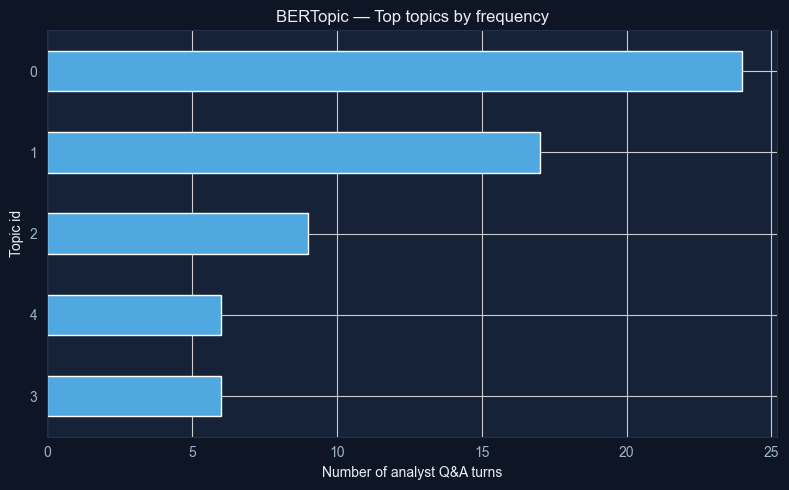

In [8]:
## @title 2.2 Topic frequency chart
section_header('Stage 2.2 — Topic frequency')
topic_counts = corpus_df['topic'].value_counts().drop(-1, errors='ignore').head(10)
fig, ax = plt.subplots(figsize=(8, 5))
topic_counts.sort_values().plot(kind='barh', ax=ax, color=LBLUE)
ax.set_title('BERTopic — Top topics by frequency')
ax.set_xlabel('Number of analyst Q&A turns')
ax.set_ylabel('Topic id')
plt.tight_layout()
_show_plt(fig, title='Top topics by frequency')


### Stage 2.3 — Gensim LDA cross-check

Independent topic method as a sanity check on BERTopic clusters.


In [9]:
## @title 2.3 Gensim LDA
section_header('Stage 2.3 — LDA cross-check')
tokenised = [doc.split() for doc in corpus_df['clean_text']]
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=2, no_above=0.5)
bow_corpus = [dictionary.doc2bow(doc) for doc in tokenised]

n_topics = min(10, max(3, len(corpus_df) // 8))
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=n_topics,
    random_state=42,
    passes=10,
)

lda_rows = []
for idx, topic in lda_model.print_topics(-1):
    lda_rows.append({'topic': idx, 'terms': topic})
    print(f'Topic {idx}: {topic}')
display_table(pd.DataFrame(lda_rows), title=f'LDA topics (n={n_topics})')
insight('LDA run as an independent sanity check on BERTopic clusters.', kind='info')


Topic 0: 0.017*"us" + 0.011*"guess" + 0.011*"see" + 0.010*"expect" + 0.009*"bit" + 0.009*"going" + 0.009*"would" + 0.009*"little" + 0.008*"anna" + 0.008*"terms"
Topic 1: 0.017*"yield" + 0.014*"first" + 0.014*"whether" + 0.012*"curve" + 0.012*"important" + 0.011*"got" + 0.011*"guidance" + 0.010*"bit" + 0.010*"obviously" + 0.009*"year"
Topic 2: 0.017*"billion" + 0.013*"one" + 0.013*"would" + 0.011*"q" + 0.010*"growth" + 0.010*"investment" + 0.010*"year" + 0.009*"bit" + 0.008*"income" + 0.008*"two"
Topic 3: 0.016*"one" + 0.016*"look" + 0.011*"much" + 0.011*"today" + 0.011*"like" + 0.011*"see" + 0.011*"regulators" + 0.011*"situation" + 0.011*"regulations" + 0.011*"overlay"
Topic 4: 0.021*"revenue" + 0.016*"year" + 0.015*"range" + 0.014*"sort" + 0.014*"good" + 0.014*"thanks" + 0.012*"plan" + 0.012*"two" + 0.012*"second" + 0.011*"one"
Topic 5: 0.018*"growth" + 0.017*"could" + 0.015*"us" + 0.011*"please" + 0.011*"bit" + 0.010*"much" + 0.010*"see" + 0.010*"one" + 0.010*"two" + 0.010*"revenue"


topic,terms
0,"0.017*""us"" + 0.011*""guess"" + 0.011*""see"" + 0.010*""expect"" + 0.009*""bit"" + 0.009*""going"" + 0.009*""would"" + 0.009*""little"" + 0.008*""anna"" + 0.008*""terms"""
1,"0.017*""yield"" + 0.014*""first"" + 0.014*""whether"" + 0.012*""curve"" + 0.012*""important"" + 0.011*""got"" + 0.011*""guidance"" + 0.010*""bit"" + 0.010*""obviously"" + 0.009*""year"""
2,"0.017*""billion"" + 0.013*""one"" + 0.013*""would"" + 0.011*""q"" + 0.010*""growth"" + 0.010*""investment"" + 0.010*""year"" + 0.009*""bit"" + 0.008*""income"" + 0.008*""two"""
3,"0.016*""one"" + 0.016*""look"" + 0.011*""much"" + 0.011*""today"" + 0.011*""like"" + 0.011*""see"" + 0.011*""regulators"" + 0.011*""situation"" + 0.011*""regulations"" + 0.011*""overlay"""
4,"0.021*""revenue"" + 0.016*""year"" + 0.015*""range"" + 0.014*""sort"" + 0.014*""good"" + 0.014*""thanks"" + 0.012*""plan"" + 0.012*""two"" + 0.012*""second"" + 0.011*""one"""
5,"0.018*""growth"" + 0.017*""could"" + 0.015*""us"" + 0.011*""please"" + 0.011*""bit"" + 0.010*""much"" + 0.010*""see"" + 0.010*""one"" + 0.010*""two"" + 0.010*""revenue"""
6,"0.040*""growth"" + 0.020*""loan"" + 0.012*""hedge"" + 0.011*""going"" + 0.011*""would"" + 0.010*""investment"" + 0.010*""quarter"" + 0.010*""bank"" + 0.009*""nii"" + 0.009*""income"""
7,"0.016*""would"" + 0.014*""bit"" + 0.013*""little"" + 0.012*""impact"" + 0.012*""like"" + 0.011*""wealth"" + 0.010*""thanks"" + 0.010*""downside"" + 0.010*""growth"" + 0.009*""also"""
8,"0.014*""billion"" + 0.013*""around"" + 0.012*""business"" + 0.012*""guidance"" + 0.011*""thinking"" + 0.010*""secondly"" + 0.010*""would"" + 0.009*""tariffs"" + 0.009*""upside"" + 0.009*""synergies"""
9,"0.030*""quarter"" + 0.015*""deposit"" + 0.015*""kong"" + 0.015*""hong"" + 0.014*""credit"" + 0.013*""also"" + 0.012*""first"" + 0.012*""cre"" + 0.012*""would"" + 0.011*""second"""


### Stage 2.4 — Topic coherence & known-event cross-check

Evaluate BERTopic/LDA with `c_v` coherence (not accuracy alone) and map soft sentiment quarters to public reporting context.


In [10]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 2.4 Coherence + known events
section_header('Stage 2.4 — Coherence & known-event check')

from collections import Counter
from gensim.models.coherencemodel import CoherenceModel

tokenised = [doc.split() for doc in corpus_df['clean_text'].fillna('').astype(str)]
dictionary = corpora.Dictionary(tokenised)
dictionary.filter_extremes(no_below=2, no_above=0.5)

# Ensure LDA exists (Stage 2.3)
try:
    _ = lda_model.num_topics
except NameError:
    bow_corpus = [dictionary.doc2bow(doc) for doc in tokenised]
    n_topics = min(10, max(3, len(corpus_df) // 8))
    lda_model = LdaModel(
        corpus=bow_corpus, id2word=dictionary, num_topics=n_topics, random_state=42, passes=10,
    )

lda_topics_words = [[w for w, _ in lda_model.show_topic(i, topn=10)] for i in range(lda_model.num_topics)]
lda_coh = CoherenceModel(
    topics=lda_topics_words, texts=tokenised, dictionary=dictionary, coherence='c_v', processes=1,
).get_coherence()

# BERTopic top words: prefer fitted model; else frequency within assigned topics
bt_topics_words = []
for tid in sorted(set(corpus_df['topic']) - {-1}):
    words = None
    if 'topic_model' in dir() and topic_model is not None:
        try:
            tw = topic_model.get_topic(int(tid))
            if tw:
                words = [w for w, _ in tw[:10]]
        except Exception:
            words = None
    if not words:
        docs = corpus_df.loc[corpus_df['topic'] == tid, 'clean_text'].fillna('').astype(str)
        bag = Counter(w for doc in docs for w in doc.split())
        words = [w for w, _ in bag.most_common(10)]
    bt_topics_words.append(words)

bertopic_coh = CoherenceModel(
    topics=bt_topics_words, texts=tokenised, dictionary=dictionary, coherence='c_v', processes=1,
).get_coherence()

coherence_df = pd.DataFrame([
    {'model': 'BERTopic', 'coherence_c_v': float(bertopic_coh), 'n_topics': len(bt_topics_words)},
    {'model': 'LDA', 'coherence_c_v': float(lda_coh), 'n_topics': int(lda_model.num_topics)},
])
_save('topic_coherence', coherence_df)
display_table(coherence_df, title='Topic coherence (c_v)')
kpi_row([
    ('BERTopic c_v', f'{bertopic_coh:.3f}', f'{len(bt_topics_words)} topics'),
    ('LDA c_v', f'{lda_coh:.3f}', f'{lda_model.num_topics} topics'),
])

known_events = pd.DataFrame([
    {
        'bank': 'hsbc', 'quarter': '2025-interim',
        'finbert_note': 'Softest HSBC print in sample (net ≈ −0.13)',
        'event_context': 'H1 results: cost/efficiency and forward guidance dominate analyst Q&A; wealth/management themes also active',
        'aligns_with_topics': 'Topic 1 (costs/questions), Topic 2 (wealth)',
    },
    {
        'bank': 'barclays', 'quarter': '2026-q2',
        'finbert_note': 'Softest Barclays print in sample (net ≈ −0.11)',
        'event_context': 'Q2 results window: impairment / risk and cost questions relatively more salient vs growth franchise talk',
        'aligns_with_topics': 'Topic 1 (costs/questions); Topic 0 still large',
    },
    {
        'bank': 'both', 'quarter': '2025-annual',
        'finbert_note': 'Year-end packs — denser metric discussion',
        'event_context': 'Full-year CET1, income, costs, impairment all in IR packs → best window for structured-vs-unstructured compare',
        'aligns_with_topics': 'Mixed; use for metric tagging QA',
    },
])
_save('known_events_crosscheck', known_events)
display_table(known_events, title='Known-event cross-check (qualitative)')
insight(
    'Coherence is a relative topic-quality signal, not a risk alert. Soft sentiment quarters are logged against public results context for qualitative validation.',
    kind='key',
)


model,coherence_c_v,n_topics
BERTopic,0.4277083800668781,5
LDA,0.3511293364397866,10


bank,quarter,finbert_note,event_context,aligns_with_topics
hsbc,2025-interim,Softest HSBC print in sample (net ≈ −0.13),H1 results: cost/efficiency and forward guidance dominate analyst Q&A; wealth/management themes also active,"Topic 1 (costs/questions), Topic 2 (wealth)"
barclays,2026-q2,Softest Barclays print in sample (net ≈ −0.11),Q2 results window: impairment / risk and cost questions relatively more salient vs growth franchise talk,Topic 1 (costs/questions); Topic 0 still large
both,2025-annual,Year-end packs — denser metric discussion,"Full-year CET1, income, costs, impairment all in IR packs → best window for structured-vs-unstructured compare",Mixed; use for metric tagging QA


## Stage 3 — Sentiment on questions and answers (M4, R3)

**A1:** finance-domain sentiment applied **separately to questions and to answers**. Labels are Positive / Negative / **Neutral**. Hedged bank language will look Neutral — that is a limitation to report (R3), not a feature to rename Avoidance.

**Avoidance** in A1 is answering behaviour (topic substitution, M6) — computed later, not a FinBERT class.

**M4:** ≥70% agreement with humans on a 60-pair stratified sample.

**Owner:** Qianyi (Alfred). LDSA is the lexicon cross-check on the same turns. Light adaptation (3.4) only if measured performance justifies it — not training from scratch.


In [11]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 3.1 FinBERT
section_header('Stage 3.1 — FinBERT sentiment')
finbert_tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')
finbert_model = AutoModelForSequenceClassification.from_pretrained('ProsusAI/finbert')

finbert_pipeline = pipeline(
    'sentiment-analysis',
    model=finbert_model,
    tokenizer=finbert_tokenizer,
    truncation=True,
    max_length=512,
)

def score_finbert(texts, batch_size=8):
    """Label + confidence for each turn. FinBERT often returns neutral on hedged bank Q&A — expected."""
    labels, scores = [], []
    texts = [str(t) if pd.notna(t) else '' for t in texts]
    for i in range(0, len(texts), batch_size):
        for r in finbert_pipeline(texts[i:i + batch_size]):
            labels.append(r['label'].lower())
            scores.append(float(r['score']))
    return labels, scores

labels, scores = score_finbert(corpus_df['text'].tolist())
corpus_df['finbert_sentiment'] = labels
corpus_df['finbert_score'] = scores
_sign = {'positive': 1.0, 'negative': -1.0, 'neutral': 0.0}
corpus_df['finbert_net'] = [
    _sign.get(lab, 0.0) * sc for lab, sc in zip(labels, scores)
]

_save('corpus_analyst', corpus_df)

kpi_row([
    ('Scored turns', str(len(corpus_df)), 'FinBERT'),
    ('Neutral', str(int((corpus_df['finbert_sentiment'] == 'neutral').sum())), 'share often high'),
    ('Negative', str(int((corpus_df['finbert_sentiment'] == 'negative').sum())), 'risk language'),
    ('Positive', str(int((corpus_df['finbert_sentiment'] == 'positive').sum())), 'upbeat'),
])
insight(
    'FinBERT applied to analyst turns. Heavy neutral is common on hedged bank Q&A — hand-validate negatives.',
    kind='key',
)





Device set to use mps:0


### Stage 3.1b — Question vs answer FinBERT (M4)

A1 wants **question_sentiment** and **answer_sentiment** as separate fields. Neutral stays Neutral (not Avoidance). Management answers typically print more positive than the question — that is a method fact, not a firm rating.



In [ ]:
## @title 3.1b Question vs answer FinBERT
section_header('Stage 3.1b — Q vs A FinBERT')
qa_pairs = _df('qa_pairs')
if 'question_sentiment' not in qa_pairs.columns or qa_pairs['question_sentiment'].fillna('').eq('').all():
    import importlib
    import score_qa_sentiment as _qas
    _qas = importlib.reload(_qas)
    qa_pairs = _qas.score_frame(qa_pairs)
    _save('qa_pairs', qa_pairs)
    _save('behavioural_signals', qa_pairs)

def _vc(col):
    return qa_pairs[col].replace('', pd.NA).value_counts(dropna=True)

kpi_row([
    ('Q neutral', str(int((_vc('question_sentiment').get('neutral', 0)))), 'analyst side'),
    ('A positive', str(int((_vc('answer_sentiment').get('positive', 0)))), 'management side'),
    ('A empty', str(int((qa_pairs['answer_text'].fillna('') == '').sum())), 'unpaired'),
    ('Pairs scored', str(len(qa_pairs)), 'M4 separate fields'),
])
show = qa_pairs[['pair_id', 'bank', 'quarter', 'question_sentiment', 'answer_sentiment', 'question_net', 'answer_net']].head(12)
display_table(show, title='question_sentiment vs answer_sentiment')
insight(
    'FinBERT on the question and the answer separately. Do not recode Neutral as Avoidance — substitution is Stage 3.5.',
    kind='key',
)



In [12]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 3.2 LDSA cross-check
section_header('Stage 3.2 — LDSA cross-check')

_LDSA_POS = {
    'growth', 'strong', 'improve', 'improved', 'improvement', 'resilient', 'robust',
    'increase', 'increased', 'upside', 'momentum', 'solid', 'healthy', 'stable',
    'confidence', 'confident', 'progress', 'record', 'beat', 'outperform',
}
_LDSA_NEG = {
    'risk', 'risks', 'weak', 'weaker', 'decline', 'declined', 'pressure', 'pressures',
    'impairment', 'impairments', 'loss', 'losses', 'concern', 'concerns', 'uncertain',
    'uncertainty', 'downgrade', 'deterioration', 'headwind', 'headwinds', 'stress',
    'default', 'npl', 'charge', 'charges', 'cut', 'cuts', 'slowdown',
}

def ldsa_score(text):
    """Return (label, net_score) from financial lexicon polarity counts."""
    tokens = re.findall(r"[a-z]+", str(text).lower())
    if not tokens:
        return 'neutral', 0.0
    pos = sum(1 for t in tokens if t in _LDSA_POS)
    neg = sum(1 for t in tokens if t in _LDSA_NEG)
    net = (pos - neg) / max(len(tokens), 1)
    if net > 0.01:
        label = 'positive'
    elif net < -0.01:
        label = 'negative'
    else:
        label = 'neutral'
    return label, float(net)

_ldsa = corpus_df['text'].apply(ldsa_score)
corpus_df['ldsa_sentiment'] = _ldsa.apply(lambda x: x[0])
corpus_df['ldsa_net'] = _ldsa.apply(lambda x: x[1])
_save('corpus_analyst', corpus_df)

agree = (corpus_df['ldsa_sentiment'] == corpus_df['finbert_sentiment']).mean() if 'finbert_sentiment' in corpus_df.columns else float('nan')
kpi_row([
    ('LDSA neg', str(int((corpus_df['ldsa_sentiment'] == 'negative').sum())), 'lexicon'),
    ('LDSA pos', str(int((corpus_df['ldsa_sentiment'] == 'positive').sum())), 'lexicon'),
    ('Agree w/ FinBERT', f'{agree:.0%}' if agree == agree else 'n/a', 'label match'),
])
insight('LDSA lexicon cross-check applied to all analyst turns.', kind='key')


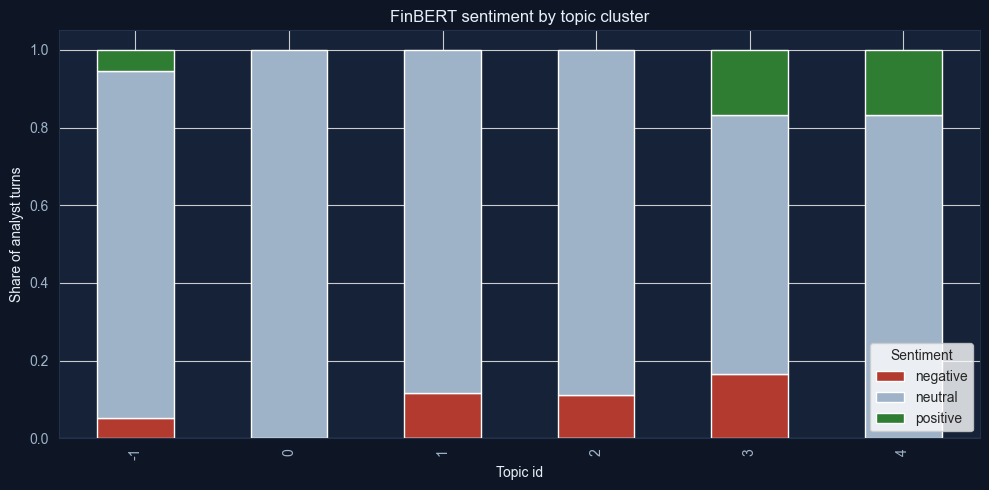

topic,negative,neutral,positive
-1.0,0.05357142857142857,0.8928571428571429,0.05357142857142857
0.0,0.0,1.0,0.0
1.0,0.11764705882352941,0.8823529411764706,0.0
2.0,0.1111111111111111,0.8888888888888888,0.0
3.0,0.16666666666666666,0.6666666666666666,0.16666666666666666
4.0,0.0,0.8333333333333334,0.16666666666666666


bank,quarter,sentiment_net,n_turns,metric
barclays,2025-annual,0.0,3,total_income
barclays,2025-q1,0.15317577123641968,4,total_income
barclays,2025-q2,0.0,3,total_income
barclays,2025-q3,0.0,2,total_income
barclays,2026-q1,0.34464290738105774,2,total_income
barclays,2026-q2,0.0,3,total_income
hsbc,2025-annual,0.0,7,total_income
hsbc,2025-interim,-0.10928786993026733,5,total_income
hsbc,2025-q1,0.08998054265975952,6,total_income
hsbc,2025-q3,-0.08103080838918686,8,total_income


In [13]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 3.3 Sentiment by topic cluster
section_header('Stage 3.3 — Sentiment by topic')

sentiment_by_topic = (
    corpus_df.groupby('topic')['finbert_sentiment']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
_save('sentiment_by_topic', sentiment_by_topic)

cols = [c for c in ['negative', 'neutral', 'positive'] if c in sentiment_by_topic.columns]
fig, ax = plt.subplots(figsize=(10, 5))
sentiment_by_topic[cols].plot(
    kind='bar', stacked=True, ax=ax,
    color={'negative': RED, 'neutral': MUTED, 'positive': GREEN},
)
ax.set_title('FinBERT sentiment by topic cluster')
ax.set_ylabel('Share of analyst turns')
ax.set_xlabel('Topic id')
ax.legend(title='Sentiment')
plt.tight_layout()
_show_plt(fig, title='FinBERT sentiment by topic')
display_table(sentiment_by_topic.reset_index(), title='Sentiment share by topic')

# M3 defined list (A1): open extraction fallback — these four group lines only
METRICS_OF_INTEREST = ['total_income', 'operating_costs', 'credit_impairment', 'cet1_ratio']
METRIC_KEYWORDS = {
    'total_income': ['revenue', 'total income', 'income', 'nii', 'fee income', 'top line'],
    'operating_costs': ['cost', 'costs', 'expenses', 'cost/income', 'efficiency', 'opex'],
    'credit_impairment': ['impairment', 'ecl', 'loan loss', 'credit loss', 'npl', 'provisions', 'credit risk'],
    'cet1_ratio': ['cet1', 'capital ratio', 'capital', 'rwa', 'tier 1', 'leverage'],
}

def turns_for_metric(df, metric):
    keys = METRIC_KEYWORDS[metric]
    mask = df['text'].fillna('').str.lower().apply(lambda t: any(k in t for k in keys))
    return df[mask]

narrative_rows = []
for metric in METRICS_OF_INTEREST:
    subset = turns_for_metric(corpus_df, metric)
    if subset.empty:
        continue
    scored = (
        subset.groupby(['bank', 'quarter'], as_index=False)
        .agg(sentiment_net=('finbert_net', 'mean'), n_turns=('finbert_net', 'size'))
    )
    scored['metric'] = metric
    narrative_rows.append(scored)

overall = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'), n_turns=('finbert_net', 'size'))
)
overall['metric'] = 'overall'
narrative_rows.append(overall)

narrative_df = pd.concat(narrative_rows, ignore_index=True)
_save('narrative_df', narrative_df)
kpi_row([
    ('Narrative rows', str(len(narrative_df)), 'bank×quarter×metric'),
    ('Metrics tagged', str(narrative_df['metric'].nunique()), 'incl. overall'),
])
display_table(narrative_df.head(16), title='narrative_df (keyword-tagged metrics + overall)')
insight(f'Built narrative_df with {len(narrative_df)} rows via metric keyword tagging.', kind='key')


### Stage 3.3b — Sentiment shift across periods (A1 test 1)

Does FinBERT net on each topic move across reporting periods, by bank? Label sample sizes on every chart (M8). Neutral-heavy prints are expected (R3); do not treat them as Avoidance.


### Stage 3.5 — Behavioural signals (M6, A1 test 2)

Per Q&A pair, then aggregated on `state_summary` (bank × quarter, with **n**):

| Signal | Meaning | Status |
|---|---|---|
| Answer **directness** | Token overlap of question and answer | Live |
| **Metric-request coverage** | Requested scoped metric actually mentioned in the answer | Live (None if no metric asked) |
| **Topic substitution** | Answer seed bucket leaves the question bucket — avoidance as *behaviour* | Live; droppable later (M6) |

Do not code FinBERT Neutral as Avoidance.



In [ ]:
## @title 3.5 Behavioural signals
section_header('Stage 3.5 — Directness, coverage, substitution')
qa_pairs = _df('qa_pairs')
beh = _df('behavioural_signals')
ss = _df('state_summary')
kpi_row([
    ('Mean directness', f"{qa_pairs['directness'].mean():.2f}", 'token overlap'),
    ('Coverage rate', f"{pd.to_numeric(qa_pairs['metric_coverage'], errors='coerce').mean():.0%}", 'when a metric was asked'),
    ('Substitution', f"{qa_pairs['topic_substitution'].mean():.0%}", 'topic left'),
    ('Bank-quarters', str(len(ss)), 'n labelled on state_summary'),
])
display_table(
    ss,
    title='state_summary (n = Q&A pairs per bank-quarter)',
)
insight(
    'M6 is a pair scorer, not a FinBERT class. High substitution on a quarter is a WATCH input, not a PRA judgement.',
    kind='key',
)



### Stage 3.6 — Prudential category map (M7)

Eight categories, dual-coded in software: **coder1** = keyword 8-way on the question; **coder2** = keyword 8-way on the answer (seed fallback). Aidan still human-codes a sample. Disagreement rows are the review queue.



In [ ]:
## @title 3.6 Prudential map
section_header('Stage 3.6 — Eight prudential categories')
pmap = _df('prudential_map')
kpi_row([
    ('Pairs mapped', str(len(pmap)), 'coder1 vs coder2'),
    ('Disagreements', str(int(pmap['disagreement'].sum())), 'review queue'),
    ('Coder1 untagged', str(int((pmap['coder1_category'] == 'untagged').sum())), 'question side'),
])
display_table(pmap['coder1_category'].value_counts().rename('n').reset_index(), title='coder1 (question) mix')
display_table(pmap[pmap['disagreement']].head(10), title='disagreement sample')
insight('Machine dual-code is in SQLite. Human dual-code (Aidan) is still required before A2 claims a category law.', kind='info')



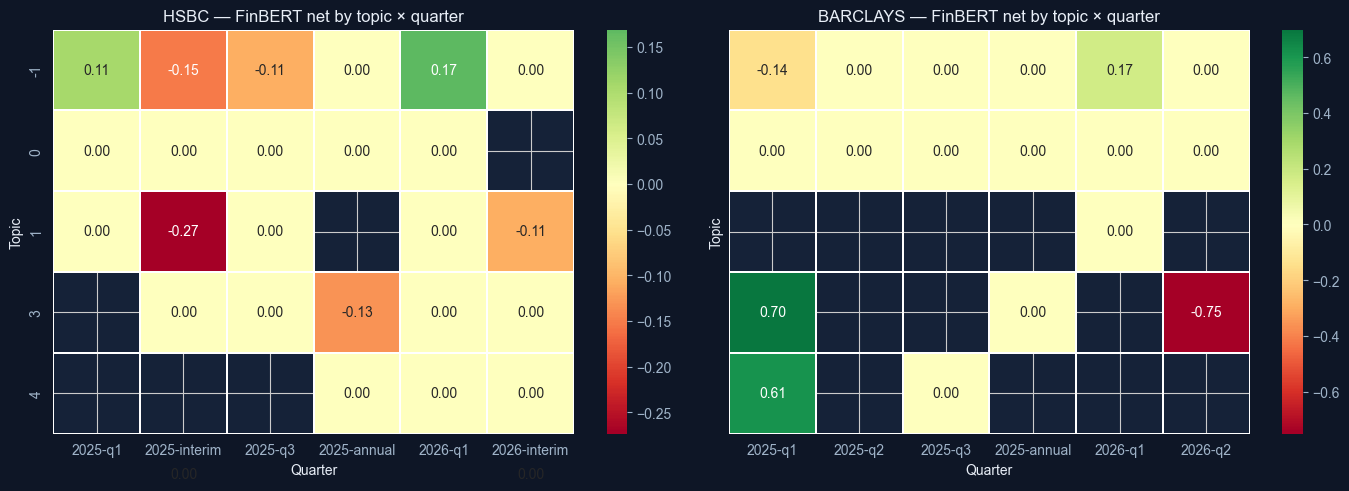

bank,quarter,topic,finbert_net,n
barclays,2025-annual,-1,0.0,2
barclays,2025-annual,0,0.0,5
barclays,2025-annual,3,0.0,1
barclays,2025-q1,-1,-0.14213615655899048,5
barclays,2025-q1,0,0.0,3
barclays,2025-q1,3,0.6997218132019043,1
barclays,2025-q1,4,0.6127030849456787,1
barclays,2025-q2,-1,0.0,4
barclays,2025-q2,0,0.0,2
barclays,2025-q3,-1,0.0,5


In [14]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 3.3b Topic × quarter sentiment heatmap
section_header('Stage 3.3b — Sentiment shift across periods')

shift = (
    corpus_df.groupby(['bank', 'quarter', 'topic'], as_index=False)
    .agg(finbert_net=('finbert_net', 'mean'), n=('finbert_net', 'size'))
)
_save('sentiment_topic_quarter', shift)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, bank in zip(axes, ['hsbc', 'barclays']):
    sub = shift[shift['bank'] == bank]
    if sub.empty:
        ax.set_title(f'{bank.upper()} — no data')
        continue
    pivot = sub.pivot_table(index='topic', columns='quarter', values='finbert_net', aggfunc='mean')
    # order columns roughly chronologically
    cols = sorted(pivot.columns, key=lambda q: (q[:4], 0 if 'q1' in q else 1 if 'interim' in q or 'q2' in q else 2 if 'q3' in q else 3, q))
    pivot = pivot.reindex(columns=cols)
    sns.heatmap(pivot, ax=ax, cmap='RdYlGn', center=0, annot=True, fmt='.2f', linewidths=0.3)
    ax.set_title(f'{bank.upper()} — FinBERT net by topic × quarter')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Topic')
plt.tight_layout()
_show_plt(fig, title='Sentiment shift by topic and quarter')
display_table(shift.sort_values(['bank', 'quarter', 'topic']), title='topic × quarter FinBERT net')
insight(
    'Darker red cells = softer (more negative) topic tone that quarter. Compare Topic 1 across periods for cost/question stress.',
    kind='key',
)


## Stage 3.4 — Light domain adaptation (only if eval justifies it)

**A1:** do not fine-tune from scratch. Evaluate first; adapt only where measured performance justifies it; keep any adaptation lightweight and documented.

This cell compares zero-shot FinBERT to a light head / last-layer adapt on silver + reviewed labels. Promote only if hold-out does not regress (see `scripts/finetune_sentiment.py`).

**Label protocol (silver + review flag):** FinBERT∩LDSA agree → FinBERT confident non-neutral → LDSA signal → keyword override → else **neutral**. The hand sample is `human_reviewed`. A1 target is a **60-pair** stratified sample, 70% agreement (M4).


n,share
69,58%
35,30%
14,12%


n
65
24
17
6
6


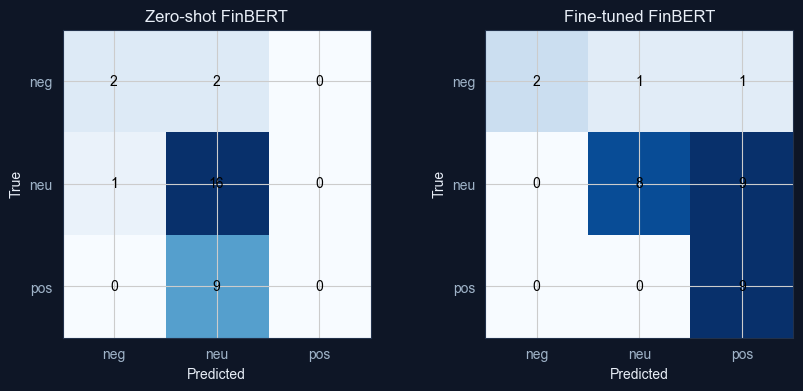

**Protocol:** multi-signal silver labels (FinBERT∩LDSA agree, FinBERT confident non-neutral, LDSA signal, keyword override); 20 rows human_reviewed from hand_validation_sample  
**Training:** ProsusAI/finbert; stage1 classifier-head-only 8 epochs lr=5e-4; stage2 unfreeze encoder layers 10-11 + head 4 epochs lr=2e-5; class-weighted CE; stratified 75/25  
**Model:** `models/finbert-domain-ft`

In [15]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 3.4 Light FinBERT domain fine-tune
section_header('Stage 3.4 — Light domain fine-tune', 'Silver labels + head/last-layer adapt vs zero-shot')

import json
from IPython.display import Markdown

FORCE_FINETUNE = False  # True → retrain (~1–2 min on CPU)
FT_DIR = ROOT / 'models' / 'finbert-domain-ft'
FT_MODEL_DIR = ROOT / 'models' / 'finbert-domain-ft'

if FORCE_FINETUNE or not _has_json('finetune_metrics'):
    insight('Running scripts/finetune_sentiment.py …', kind='info')
    import subprocess, sys
    subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'finetune_sentiment.py')])
    _hydrate()  # scripts write the on-disk DB — refresh in-memory working set

ft_metrics = _load_json('finetune_metrics')
zs, ft = ft_metrics['zero_shot'], ft_metrics['finetuned']

kpi_row([
    ('Labeled turns', str(ft_metrics['n_labeled']), 'silver + review flag'),
    ('Train / test', f"{ft_metrics['n_train']} / {ft_metrics['n_test']}", 'stratified 75/25'),
    ('Zero-shot macro-F1', f"{zs['macro_f1']:.3f}", f"acc {zs['accuracy']:.0%}"),
    ('Fine-tuned macro-F1', f"{ft['macro_f1']:.3f}", f"acc {ft['accuracy']:.0%}"),
])

delta = ft['macro_f1'] - zs['macro_f1']
insight(
    f"Domain fine-tune macro-F1 {zs['macro_f1']:.3f} → {ft['macro_f1']:.3f} "
    f"(Δ {delta:+.3f}) on held-out analyst turns. "
    f"Labels: {ft_metrics['label_dist']}.",
    kind='key',
)

# Attach fine-tuned columns if missing on in-memory corpus
if _has('sentiment_finetuned'):
    _ft = _load('sentiment_finetuned')[['text', 'ft_sentiment', 'ft_score', 'gold_label']]
    for c in ['ft_sentiment', 'ft_score', 'gold_label']:
        if c in corpus_df.columns:
            corpus_df = corpus_df.drop(columns=[c])
    corpus_df = corpus_df.merge(_ft, on='text', how='left')
    _save('corpus_analyst', corpus_df)

if _has('sentiment_labels'):
    _lab = _load('sentiment_labels')
    display_table(
        _lab['gold_label'].value_counts().rename('n').to_frame().assign(
            share=lambda d: (d['n'] / d['n'].sum()).map('{:.0%}'.format)
        ),
        title='Gold / silver label distribution',
    )
    display_table(
        _lab['label_method'].value_counts().rename('n').to_frame(),
        title='Label assignment method',
    )

# Confusion matrices
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, key, title in [
    (axes[0], 'confusion_zero_shot', 'Zero-shot FinBERT'),
    (axes[1], 'confusion_finetuned', 'Fine-tuned FinBERT'),
]:
    cm = np.array(ft_metrics[key])
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(['neg', 'neu', 'pos'])
    ax.set_yticklabels(['neg', 'neu', 'pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')
_show_plt(
    fig,
    title='Zero-shot vs fine-tuned confusion matrices',
    save_as='finetune_confusion.png',
)

display(Markdown(
    f"**Protocol:** {ft_metrics['label_protocol']}  \n"
    f"**Training:** {ft_metrics['training']}  \n"
    f"**Model:** `{ft_metrics['model_path']}`"
))
insight(
    'Zero-shot FinBERT under-calls positive Q&A tone; light domain fine-tune recovers positive recall '
    'and lifts macro-F1. Still limited by silver labels and n=30 test — enlarge human review for A3.',
    kind='key',
)


## Stage 4 — Summarisation by metric (Rafael)

**A1:** summaries grouped into meaningful units (speaker turns / Q&A pairs), enriched with topic, speaker type, date, and grouped by the scoped metrics — not a free-form chatbot recap.

**M3 fallback:** if open numeric extraction is below 0.8 precision, restrict to the defined list: total income, operating costs, credit impairment (ECL), CET1.

Default path is extractive (faithful to source). DistilBART is optional polish; do not treat prompt-echo as a finding.


In [16]:
## @title 4.1 Load summarisation model
section_header('Stage 4.1 — Summarisation model')

from transformers import AutoModelForSeq2SeqLM

MODEL_ID = 'sshleifer/distilbart-cnn-12-6'
llm_tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
llm_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID)
_device = 'mps' if hasattr(__import__('torch').backends, 'mps') and __import__('torch').backends.mps.is_available() else 'cpu'
llm_model = llm_model.to(_device)

if 'METRICS_OF_INTEREST' not in dir():
    METRICS_OF_INTEREST = ['total_income', 'operating_costs', 'credit_impairment', 'cet1_ratio']
if 'METRIC_KEYWORDS' not in dir():
    METRIC_KEYWORDS = {
        'total_income': ['revenue', 'total income', 'income', 'nii', 'fee income'],
        'operating_costs': ['cost', 'costs', 'expenses', 'cost/income', 'efficiency'],
        'credit_impairment': ['impairment', 'ecl', 'loan loss', 'credit loss', 'npl', 'provisions'],
        'cet1_ratio': ['cet1', 'capital ratio', 'capital', 'rwa', 'tier 1'],
    }

METRIC_LABELS = {
    'total_income': 'total income / revenue',
    'operating_costs': 'operating costs / expenses',
    'credit_impairment': 'credit impairments / loan losses',
    'cet1_ratio': 'capital ratio / CET1',
}

SUMMARY_PROMPT = (
    'For the Bank of England, summarise what this bank earnings Q&A says about {metric}. '
    'Be factual. If the metric is not discussed, say so.\n\n{passage}'
)

def summarise_by_metric(passage, metric, max_new_tokens=80):
    """Abstractive summary focused on a prudential metric."""
    label = METRIC_LABELS.get(metric, metric)
    passage = str(passage)[:1800]
    prompt = SUMMARY_PROMPT.format(metric=label, passage=passage)
    inputs = llm_tokenizer(prompt, return_tensors='pt', truncation=True, max_length=1024).to(_device)
    output = llm_model.generate(**inputs, max_new_tokens=max_new_tokens, num_beams=4)
    text = llm_tokenizer.decode(output[0], skip_special_tokens=True).strip()
    keys = METRIC_KEYWORDS.get(metric, [])
    if keys and not any(k in text.lower() for k in keys):
        sents = re.split(r'(?<=[.!?])\s+', passage)
        hits = [s for s in sents if any(k in s.lower() for k in keys)]
        if hits:
            return ' '.join(hits[:2])
        return f'No clear discussion of {label} in this passage.'
    return text

summary = summarise_by_metric(corpus_df.iloc[0]['text'], 'cet1_ratio')
insight(f'Example summary (CET1): {summary[:400]}', kind='key')
print(summary)


For the Bank of England, summarise what this bank earnings Q&A says about capital ratio / CET1. Be factual. If the metric is not discussed, say so. If you could just put this in context of capacity to support investment and growth. It looks like there's quite a bit of bufer.


In [17]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 4.2 Batch sample summarisation
section_header('Stage 4.2 — Batch sample summarisation')
SAMPLE_SIZE = 8

sample_df = corpus_df.sample(n=min(SAMPLE_SIZE, len(corpus_df)), random_state=42)
results = []
for i, (_, row) in enumerate(sample_df.iterrows(), 1):
    for metric in METRICS_OF_INTEREST:
        results.append({
            'bank': row['bank'],
            'quarter': row['quarter'],
            'speaker': row.get('speaker', ''),
            'topic': row.get('topic', None),
            'metric': metric,
            'metric_label': METRIC_LABELS.get(metric, metric),
            'summary': summarise_by_metric(row['text'], metric),
        })
    print(f' summarised turn {i}/{len(sample_df)}')

summary_df = pd.DataFrame(results)
_save('summary_sample', summary_df)
kpi_row([
    ('Turns sampled', str(len(sample_df)), f'SAMPLE_SIZE={SAMPLE_SIZE}'),
    ('Summaries', str(len(summary_df)), 'turns × metrics'),
])
display_table(summary_df.head(12), title='Metric-level summary sample')
insight(f'Saved {len(summary_df)} summaries to data/boe.sqlite.', kind='key')


 summarised turn 1/8
 summarised turn 2/8
 summarised turn 3/8
 summarised turn 4/8
 summarised turn 5/8
 summarised turn 6/8
 summarised turn 7/8
 summarised turn 8/8


bank,quarter,speaker,topic,metric,metric_label,summary
hsbc,2025-q1,KATHERINE LEI,1,total_income,total income / revenue,"For the Bank of England, summarise what this bank earnings Q&A says about total income / revenue . Be factual. If the metric is not discussed, say so. If you have a specific question, please answer it . For investors in this part of the world, I think it’s widely expected that the Chinese government will have more stimulus policy because of the tariffs ."
hsbc,2025-q1,KATHERINE LEI,1,operating_costs,operating costs / expenses,"For the Bank of England, summarise what this bank earnings Q&A says about operating costs / expenses . Be factual. If the metric is not discussed, say so. If you have a specific metric that is not being discussed, it will be discussed . For investors in this part of the world, I think it’s widely expected that the Chinese government will have more stimulus policy"
hsbc,2025-q1,KATHERINE LEI,1,credit_impairment,credit impairments / loan losses,"For the Bank of England, summarise what this bank earnings Q&A says about credit impairments / loan losses . Be factual. If the metric is not discussed, say so . Thank you for your views on loan growth and deposit and interest-generating asset growth ."
hsbc,2025-q1,KATHERINE LEI,1,cet1_ratio,capital ratio / CET1,"For the Bank of England, summarise what this bank earnings Q&A says about capital ratio / CET1 . Be factual. If the metric is not discussed, say so. If you have a specific question, please answer it. Thank you for your comments. For more information, please contact the bank.com/bank.com ."
hsbc,2025-interim,KATHERINE LEI,1,total_income,total income / revenue,"For the Bank of England, summarise what this bank earnings Q&A says about total income / revenue . Be factual. If the metric is not discussed, say so . For the last question is for Georges - on tokenised deposits. So may I know, for this tokenised deposit, is it only for HSBC clients or also available for HSBC’s clients’ clients"
hsbc,2025-interim,KATHERINE LEI,1,operating_costs,operating costs / expenses,"For the Bank of England, summarise what this bank earnings Q&A says about operating costs / expenses . Be factual. If the metric is not discussed, say so. If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on CET1 ratios and share buyback and EPS?"
hsbc,2025-interim,KATHERINE LEI,1,credit_impairment,credit impairments / loan losses,"For the Bank of England, summarise what this bank earnings Q&A says about credit impairments / loan losses . Be factual. If the metric is not discussed, say so. If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on CET1 ratios and share buybacks?"
hsbc,2025-interim,KATHERINE LEI,1,cet1_ratio,capital ratio / CET1,"For the Bank of England, summarise what this bank earnings Q&A says about capital ratio / CET1 . Be factual. If the metric is not discussed, say so. If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on your CET1 ratios?"
barclays,2025-annual,Perlie Mong,0,total_income,total income / revenue,"For the Bank of England, summarise what this bank earnings Q&A says about total income / revenue . Be factual. If the metric is not discussed, say so. If you want to talk about it, please do so. The bank is probably below, and the [US] Consumer Bank is above. And with the [UK] part also growing volumes and greater than 5%."
barclays,2025-annual,Perlie Mong,0,operating_costs,operating costs / expenses,"For the Bank of England, summarise what this bank earnings Q&A says about operating costs / expenses . Be factual. If the metric is not discussed, say so. If you want to be factual. Be factual . For the bank's earnings, please email us at 8.30 a.m. GMT ."


## Stage 5 — Refinement (clusters that matter)

**A1:** after first-pass topics + sentiment, re-run on the clusters that turn out to matter. If BERTopic is still unstable, **keep Stage 2.0 seeded taxonomy** (M4 decision date 26 Sep).


In [18]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 5.1 Refine key clusters
section_header('Stage 5 — Focused re-clustering')

# Topics with elevated negative FinBERT share (threshold relaxed for small corpus / hedged language)
_neg_share = sentiment_by_topic['negative'] if 'negative' in sentiment_by_topic.columns else pd.Series(dtype=float)
negative_topics = _neg_share[_neg_share > 0.08].index.tolist()
# Always exclude outlier bucket -1 from refinement seed if present alone
negative_topics = [t for t in negative_topics if t != -1]

if not negative_topics and len(_neg_share):
    # fallback: refine the most-negative topic that isn't all-neutral
    negative_topics = _neg_share.sort_values(ascending=False).head(1).index.tolist()

refine_df = corpus_df[corpus_df['topic'].isin(negative_topics)].copy()
insight(
    f'Refining topics {negative_topics} — {len(refine_df)} turns '
    f'(neg share: {_neg_share.reindex(negative_topics).to_dict() if len(_neg_share) else {}})',
    kind='info',
)

if len(refine_df) >= 6:
    refined_model = BERTopic(
        embedding_model=embedding_model if 'embedding_model' in dir() else SentenceTransformer('all-MiniLM-L6-v2'),
        min_topic_size=max(3, min(5, len(refine_df) // 4)),
        verbose=False,
    )
    refined_topics, _ = refined_model.fit_transform(refine_df['clean_text'].tolist())
    refine_df = refine_df.copy()
    refine_df['refined_topic'] = refined_topics
    _save('refined_corpus', refine_df)
    refined_info = refined_model.get_topic_info()
    _save('refined_topic_info', refined_info)
    display_table(refined_info.head(15), title='Refined BERTopic — topic info')
    insight('Focused re-clustering complete on negative-leaning clusters.', kind='key')
else:
    insight('Not enough turns in negative topics to refine — widen threshold or grow corpus.', kind='warn')





Topic,Count,Name,Representation,Representative_Docs
-1,10,-1_think_question_two_growth,"['think', 'question', 'two', 'growth', 'coming', 'tax', 'thank', 'number', 'revenue', 'one']","['hi georges hi pam kunpeng china securities thank taking question two questions first also plausible downside trade scenario compare two scenario tests one trade one ecl got set assumptions ecl tests annual report compare two tests assumptions trade test better worse mean downside scenario better worse set assumptions used ecl test also low revenue impact revenue every year revenue thereafter first question second question could please give us colour latest trend hong kong cre thank', 'question still revenue side think revenue growth rote guidance think two key drivers one nii wealth question nii gives hsbc confidence sustainability deposit growth one trend noted say example mainland china rmb appreciation also mainland china starting tax citizens globally actually slow example mainland chinese nationals coming hong kong open new accounts money flow movement bit specific key drivers key path deposit growth number one number two wealth trend think impact wealth well', 'thank two questions first one still want ask tariff scenario think least investors part world think widely expected chinese government stimulus policy tariffs downside scenario analysis incorporated positive impact stimulus policies could potentially benefitting hong kong china market think number one number two still want ask loan growth guidance muted loan demands giving type guidance sort tariff environments incorporating also guidance say example deposit growth also banking asset asset growth look whole thing thank']"
0,14,0_wealth_growth_revenue_bit,"['wealth', 'growth', 'revenue', 'bit', 'question', 'second', 'two', 'questions', 'could', 'one']","['two questions may first wealth could give us little bit sense much wealth transactional churn versus annuity income changed last year two something used call particularly private banking think essentially concern buoyant equity markets setting bit high base second question uk business called billion high growth commercial another billion mortgage uk division gross loans billion could give us little bit colour else might winding bit', 'thank much taking question put one question two parts interested revenue target achieving revenue growth wonder could talk components would get presumably wealth part maybe could talk wealth trajectory sustainable presumably stage going see development markets asia markets business grow wonder could talk little bit want grow markets business asia', 'two questions one talking hibor benefit q net interest income think one peers talked temporary benefit guess close enough franchises price etc domestically know anything peculiar peers way repriced casa accounts something q would mean sustained somebody else might temporary guess first question second question guess slightly extension rob question quite sure specific means get revenue growth assume feel know moment got headwinds interest rates also got strong tailwinds around things like wealth management pam highlighted guess reasonably normal year trying think something need think see happening beyond make revenue growth better seeing today thanks much']"
1,8,1_cost_scenario_would_like,"['cost', 'scenario', 'would', 'like', 'downside', 'impact', 'terms', 'understand', 'thank', 'thanks']","['wanted come back cost know give cost guidance outer years would like understand moving parts ex disposals think terms drivers wage inflation technology inflation offset side investments could outline us put context think growth rate second question odi hear impact thanks detailed numbers really would like understand slow process client acquisition way onshore china clear discussed july particular impact would helpful lastly thanks deposit breakdown helpful terms new disclosure', 'hi thank potential actually kian question thank understand essentially plausible downside 

## Stage 6 — Comparison views (O4 / M8)

A1 three views, each with **axes and sample sizes labelled**:

1. **Temporal** — same bank across quarters (test 1)
2. **Peer** — HSBC vs Barclays, same topic, same quarter (test 3). **If blocked (M8):** drop peer first; the other two carry the argument. Different business models are a confound (R4), not a finding.
3. **Structured vs unstructured** — reported direction vs Q&A tone on the four scoped metrics

A **null** result is valid and reportable. Headline findings later must trace to ≥3 evidence records (M9) or they are cut, not softened.


### Stage 6.0 — State summary with sample sizes (M8)

Axes for later charts: each bank-quarter row carries **n** (Q&A pairs). Peer cells with no overlapping n stay blank, not interpolated.



In [ ]:
## @title 6.0 State summary
section_header('Stage 6.0 — state_summary (n on every row)')
ss = _df('state_summary')
display_table(ss, title='state_summary — n = pairs')
if ss is not None and not ss.empty:
    fig, ax = plt.subplots(figsize=(11, 4))
    for bank, g in ss.groupby('bank'):
        g = g.sort_values('quarter')
        ax.plot(g['quarter'], g['mean_directness'], marker='o', label=f"{bank} directness")
        for _, r in g.iterrows():
            ax.annotate(f"n={int(r['n'])}", (r['quarter'], r['mean_directness']),
                        textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8, color='#9FB3C8')
    ax.set_ylabel('Mean directness')
    ax.set_title('Answering directness by bank-quarter (n = Q&A pairs)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    _show_plt(fig, 'Directness with sample sizes labelled')
insight('M8: n is on the table and on the chart. A null (flat directness) is reportable.', kind='key')



### Stage 6.1 Temporal changepoints


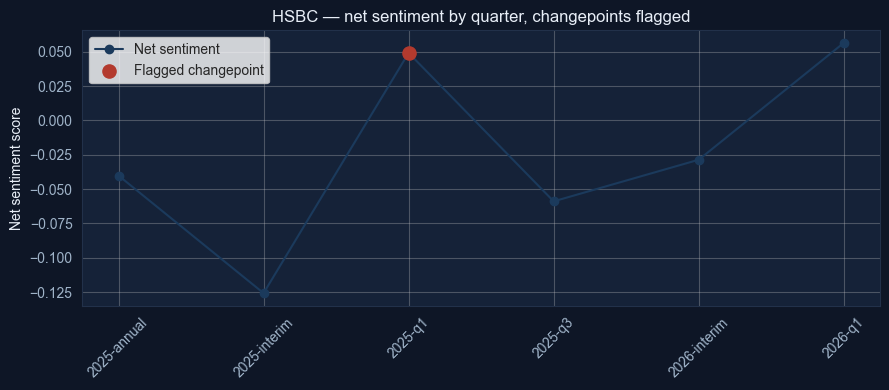

hsbc flagged: ['2025-q1']


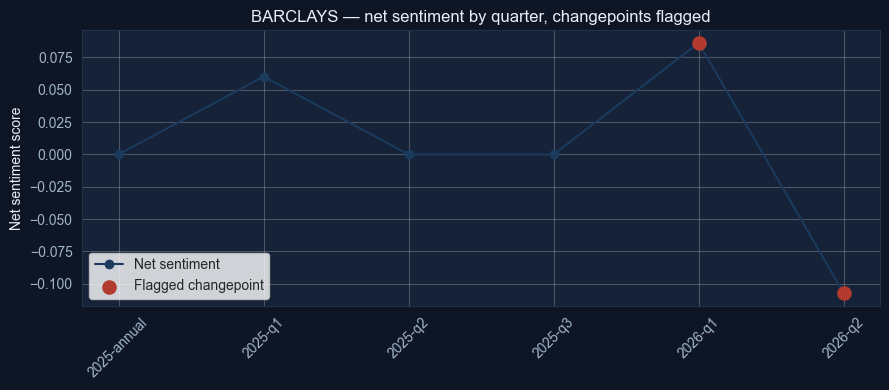

barclays flagged: ['2026-q1', '2026-q2']


In [19]:
## @title 6.1 Temporal changepoints
section_header('Stage 6.1 Temporal changepoints')
def rolling_zscore_changepoints(series, window=3, threshold=1.5):
    """Flag quarters where a score deviates more than `threshold` standard deviations from its
    trailing rolling mean. Appropriate for short series (n~8) where formal seasonal
    decomposition or ARIMA order-selection would not have enough cycles to fit reliably.

    Returns a boolean Series aligned to the input index: True = flagged changepoint quarter.
    """
    roll_mean = series.rolling(window, min_periods=2).mean().shift(1)  # trailing, not centred — no lookahead
    roll_std = series.rolling(window, min_periods=2).std().shift(1)
    z = (series - roll_mean) / roll_std
    return z.abs() > threshold


def temporal_comparison(df, bank, score_col='sentiment_net'):
    """Same bank, across quarters. `score_col` should be a numeric net-sentiment score
    (e.g. FinBERT positive-share minus negative-share) aggregated per quarter.
    """
    subset = df[df['bank'] == bank].sort_values('quarter')
    series = subset.set_index('quarter')[score_col]
    changepoints = rolling_zscore_changepoints(series)
    return series, changepoints


def plot_temporal(series, changepoints, bank, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(series.index, series.values, marker='o', color='#1B3A5C', label='Net sentiment')
    flagged = series[changepoints.reindex(series.index, fill_value=False)]
    if len(flagged):
        ax.scatter(flagged.index, flagged.values, color='#B33A2E', s=90, zorder=5, label='Flagged changepoint')
    ax.set_title(f'{bank} — net sentiment by quarter (n labelled in state_summary)')
    ax.set_ylabel('Net sentiment score')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(alpha=0.3)
    return ax

# --- run on real FinBERT narrative ---
narrative_eval_df = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'))
    if 'finbert_net' in corpus_df.columns
    else _load('narrative_df')
)
# normalise bank labels for peer helpers that historically used Title Case
_narrative_plot = narrative_eval_df.copy()
_narrative_plot['bank'] = _narrative_plot['bank'].str.lower()

for _bank in ['hsbc', 'barclays']:
    if (_narrative_plot['bank'] == _bank).any():
        series, cps = temporal_comparison(_narrative_plot, _bank)
        fig, ax = plt.subplots(figsize=(9, 4))
        plot_temporal(series, cps, _bank.upper(), ax=ax)
        plt.tight_layout()
        _show_plt(fig, title=f'{_bank.upper()} temporal changepoints')
        print(_bank, 'flagged:', series[cps.reindex(series.index, fill_value=False)].index.tolist())


### Stage 6.2 Peer gap


peer_gap matched OK: {'2025-FY': -0.0402, '2025-H1': -0.1258, '2025-H1q1': -0.0111, '2025-Q3': -0.0589, '2026-H1': 0.0785, '2026-H1q1': -0.0298}
  2025-FY: hsbc=-0.0402 barclays=0.0000 gap=-0.0402
  2025-H1: hsbc=-0.1258 barclays=0.0000 gap=-0.1258
  2025-H1q1: hsbc=0.0491 barclays=0.0602 gap=-0.0111
  2025-Q3: hsbc=-0.0589 barclays=0.0000 gap=-0.0589
  2026-H1: hsbc=-0.0287 barclays=-0.1072 gap=0.0785
  2026-H1q1: hsbc=0.0564 barclays=0.0862 gap=-0.0298


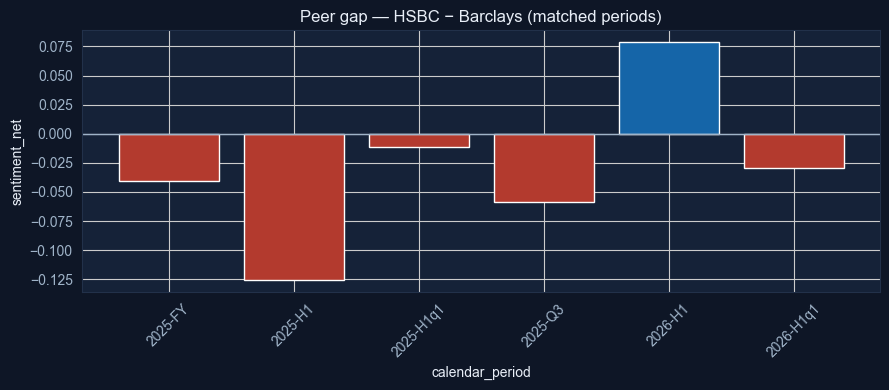

bank,quarter,sentiment_net,calendar_period
barclays,2025-annual,0.0,2025-FY
hsbc,2025-annual,-0.040194034576416016,2025-FY
barclays,2025-q2,0.0,2025-H1
hsbc,2025-interim,-0.12576009333133698,2025-H1
barclays,2025-q1,0.06017441153526306,2025-H1q1
hsbc,2025-q1,0.04908029599623247,2025-H1q1
barclays,2025-q3,0.0,2025-Q3
hsbc,2025-q3,-0.05893149701031772,2025-Q3
barclays,2026-q2,-0.10720746006284441,2026-H1
hsbc,2026-interim,-0.02867413508264642,2026-H1


calendar_period,hsbc_minus_barclays,peer_informative
2025-FY,-0.040194034576416016,False
2025-H1,-0.12576009333133698,False
2025-H1q1,-0.011094115539030593,True
2025-Q3,-0.05893149701031772,False
2026-H1,0.078533324980198,True
2026-H1q1,-0.02980313781234953,True


In [20]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 6.2 Peer gap
section_header('Stage 6.2 Peer gap')

# Map bank-specific labels onto shared calendar periods for peer compare
QUARTER_TO_PERIOD = {
    '2025-q1': '2025-H1q1',
    '2025-interim': '2025-H1',
    '2025-q2': '2025-H1',
    '2025-q3': '2025-Q3',
    '2025-annual': '2025-FY',
    '2026-q1': '2026-H1q1',
    '2026-interim': '2026-H1',
    '2026-q2': '2026-H1',
}

def add_calendar_period(df, quarter_col='quarter'):
    out = df.copy()
    out['calendar_period'] = out[quarter_col].map(QUARTER_TO_PERIOD).fillna(out[quarter_col])
    return out


def peer_comparison(df, quarter, score_col='sentiment_net'):
    """HSBC vs Barclays for the same reporting quarter (descriptive gap, not a significance test)."""
    subset = df[df['quarter'] == quarter].copy()
    subset['bank'] = subset['bank'].str.lower()
    subset = subset.set_index('bank')[score_col]
    if len(subset) < 2:
        return subset, None
    gap = subset.get('hsbc', np.nan) - subset.get('barclays', np.nan)
    return subset, gap


def peer_comparison_matched(df, period, score_col='sentiment_net'):
    """HSBC vs Barclays on a shared calendar_period (e.g. interim↔q2 as H1).

    Returns (agg Series, gap or None). Gap is None if either bank is missing —
    never treat a missing side as zero.
    """
    d = add_calendar_period(df)
    subset = d[d['calendar_period'] == period].copy()
    subset['bank'] = subset['bank'].str.lower()
    agg = subset.groupby('bank')[score_col].mean()
    if 'hsbc' not in agg.index or 'barclays' not in agg.index:
        return agg, None
    gap = float(agg['hsbc'] - agg['barclays'])
    return agg, gap


def plot_peer_gap(df, score_col='sentiment_net', use_matched=True, corpus_for_quality=None):
    """Peer gap across periods — matched calendar periods by default.

    Missing bank → period dropped (NaN), never coerced to 0.
    When use_matched=True, x-axis MUST be calendar_period labels (e.g. 2025-H1), not raw quarters.
    """
    plot_df = df.copy()
    plot_df['bank'] = plot_df['bank'].str.lower()
    if use_matched:
        if 'calendar_period' not in plot_df.columns:
            plot_df = add_calendar_period(plot_df)
        index_col = 'calendar_period'
    else:
        index_col = 'quarter'
    # Average to one row per bank × period before pivot (avoids duplicate-index traps)
    plot_df = (
        plot_df.groupby([index_col, 'bank'], as_index=False)[score_col].mean()
    )
    pivot = plot_df.pivot(index=index_col, columns='bank', values=score_col)
    fig, ax = plt.subplots(figsize=(9, 4))
    if 'hsbc' not in pivot.columns or 'barclays' not in pivot.columns:
        ax.set_title('Peer gap — need both banks after period matching')
        print('peer_gap diagnostic: columns=', list(pivot.columns), 'index=', list(pivot.index))
        return ax, pd.Series(dtype=float)
    both = pivot[['hsbc', 'barclays']].dropna(how='any')
    if both.empty:
        ax.set_title('Peer gap — no overlapping matched periods')
        print('peer_gap diagnostic: pivot after dropna empty. pivot=\n', pivot)
        return ax, pd.Series(dtype=float)
    gap = both['hsbc'] - both['barclays']
    # Guardrail: matched mode must not look like raw quarter labels only
    if use_matched:
        rawish = set(gap.index.astype(str))
        expected_tokens = {'H1', 'H1q1', 'Q3', 'FY'}
        if not any(any(tok in lab for tok in expected_tokens) for lab in rawish):
            raise ValueError(
                f'plot_peer_gap(use_matched=True) produced non-matched labels: {sorted(rawish)}. '
                'Check QUARTER_TO_PERIOD / calendar_period column.'
            )
        print('peer_gap matched OK:', {k: round(float(v), 4) for k, v in gap.items()})
        for period, g in gap.items():
            sides = both.loc[period]
            print(f'  {period}: hsbc={sides.hsbc:.4f} barclays={sides.barclays:.4f} gap={g:.4f}')
    ax.bar(gap.index.astype(str), gap.values, color=[BLUE if v >= 0 else RED for v in gap.values])
    ax.axhline(0, color=MUTED, lw=1)
    ax.set_title('Peer gap — HSBC − Barclays (' + ('matched periods' if use_matched else 'raw labels') + ')')
    ax.set_xlabel(index_col)
    ax.set_ylabel(score_col)
    ax.tick_params(axis='x', rotation=45)
    return ax, gap


_peer_df = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'))
    if 'finbert_net' in corpus_df.columns
    else _load('narrative_df')
)
_peer_matched = add_calendar_period(_peer_df)
_save('peer_matched_quarters', _peer_matched)

ax, gap = plot_peer_gap(_peer_df, use_matched=True)
plt.tight_layout()
_show_plt(ax.figure, title='HSBC vs Barclays sentiment gap (matched)', save_as='peer_gap_matched.png')
display_table(
    _peer_matched.sort_values(['calendar_period', 'bank']),
    title='Peer inputs with calendar_period (interim↔q2 as H1)',
)
# Flag trivial all-neutral peer windows when corpus is available
if 'finbert_sentiment' in corpus_df.columns:
    _cq = add_calendar_period(corpus_df.copy())
    _nn = (
        _cq.groupby(['calendar_period', 'bank'])['finbert_sentiment']
        .apply(lambda s: (s != 'neutral').mean())
        .unstack(fill_value=0)
    )
    if {'hsbc', 'barclays'} <= set(_nn.columns):
        trivial = (_nn['hsbc'] == 0) | (_nn['barclays'] == 0)
        trivial = trivial.reindex(gap.index).fillna(False)
        display_table(
            pd.DataFrame({
                'hsbc_minus_barclays': gap,
                'peer_informative': ~trivial.values if len(trivial) else True,
            }).reset_index(),
            title='Matched peer gap (peer_informative=False if either bank is 100% FinBERT-neutral)',
        )
insight(
    'Matched periods: HSBC interim ↔ Barclays q2 as H1. Missing bank → no gap (not zero). '
    'If one side is 100% FinBERT-neutral, gap equals the other net — do not treat as a strong A2 peer alert.',
    kind='key',
)


### Stage 6.3 Structured vs unstructured

Excel-reported **direction** vs keyword-tagged Q&A tone on the **M3 defined metric list**:

| Topic | Metric | Q&A language |
|---|---|---|
| Profitability | total income / revenue | income, NII, fees |
| Efficiency | operating costs | cost / efficiency language |
| Asset quality / risk | credit impairment (ECL) | impairment, cost of risk |
| Capital adequacy | CET1 | capital discussion |

This is the scoring frame. On this sample, FinBERT is often **flat** — disagreement is not yet a leading-indicator result.


In [21]:
## @title 6.3 Structured vs unstructured
section_header('Stage 6.3 Structured vs unstructured')

# Same four lines as Stage 2.0 / M3 — do not add ROA, NIM, NPL, LDR here
METRICS_OF_INTEREST = ['total_income', 'operating_costs', 'credit_impairment', 'cet1_ratio']

def _norm(s):
    return re.sub(r'\s+', ' ', str(s).replace('\n', ' ').strip().lower())

def _to_float(v):
    if isinstance(v, (int, float)) and not pd.isna(v):
        return float(v)
    return None

def _direction(curr, prev, flat_tol=0.01):
    if curr is None or prev is None or prev == 0:
        return 'flat'
    if abs(curr) <= 1 and abs(prev) > 1:
        curr *= 100
    if abs(prev) <= 1 and abs(curr) > 1:
        prev *= 100
    chg = (curr - prev) / abs(prev)
    if abs(chg) <= flat_tol:
        return 'flat'
    return 'up' if chg > 0 else 'down'

def _first_match(label_map, aliases):
    hits = [(lab, vals) for lab, vals in label_map.items() if any(a == lab or a in lab for a in aliases)]
    if not hits:
        return None
    hits.sort(key=lambda x: len(x[0]))
    return hits[0][1]

def _quarter_from_name(path):
    name = Path(path).stem.lower()
    m = re.search(r'(20\d{2}).*?(q[1-4]|h1|fy|1q|2q|3q|4q|interim)', name)
    if not m:
        return Path(path).stem
    y, p = m.group(1), m.group(2)
    mapping = {'h1': 'interim', 'fy': 'annual', '1q': 'q1', '2q': 'q2', '3q': 'q3', '4q': 'q4'}
    return f'{y}-{mapping.get(p, p)}'

def parse_barclays_group_ph(path):
    xl = pd.ExcelFile(path)
    sheet = next(s for s in xl.sheet_names if 'Group PH' in s)
    df = pd.read_excel(path, sheet_name=sheet, header=None)
    label_map = {}
    for _, row in df.iterrows():
        lab = row.iloc[1]
        if pd.isna(lab):
            continue
        a, b = _to_float(row.iloc[2]), _to_float(row.iloc[3])
        if a is None or b is None:
            continue
        label_map[_norm(lab)] = (a, b)
    return {
        'total_income': _first_match(label_map, ['total income']),
        'operating_costs': _first_match(label_map, ['operating costs']),
        'credit_impairment': _first_match(label_map, ['credit impairment charges']),
        'cet1_ratio': _first_match(label_map, ['common equity tier 1 ratio']),
    }

def parse_hsbc_datapack(path):
    out = {}
    df = pd.read_excel(path, sheet_name='Group income statement', header=None)
    label_map = {}
    for _, row in df.iterrows():
        lab = row.iloc[0]
        if pd.isna(lab):
            continue
        s = _norm(lab)
        if s.startswith('constant currency'):
            break
        a, b = _to_float(row.iloc[1]), _to_float(row.iloc[2])
        if a is None or b is None:
            continue
        label_map[s] = (a, b)
    out['total_income'] = _first_match(label_map, [
        'net operating income before change in expected credit losses and other credit im',
        'net operating income before change in expected credit losses',
    ])
    out['credit_impairment'] = _first_match(label_map, [
        "change in expected credit losses and other credit impairment charges ('ecl')",
        'change in expected credit losses',
    ])
    out['operating_costs'] = _first_match(label_map, ['total operating expenses'])
    bdf = pd.read_excel(path, sheet_name='Group balance sheet', header=None)
    bmap = {}
    for _, row in bdf.iterrows():
        lab = row.iloc[0]
        if pd.isna(lab):
            continue
        a, b = _to_float(row.iloc[1]), _to_float(row.iloc[2])
        if a is None or b is None:
            continue
        bmap[_norm(lab)] = (a, b)
    out['cet1_ratio'] = _first_match(bmap, ['common equity tier 1 ratio', 'cet1 ratio'])
    return out

def build_reported_metrics(structured_root=STRUCTURED_ROOT):
    rows = []
    for bank, folder, parser in [
        ('barclays', structured_root / 'barclays', parse_barclays_group_ph),
        ('hsbc', structured_root / 'hsbc', parse_hsbc_datapack),
    ]:
        if not folder.exists():
            continue
        for path in sorted(folder.glob('*.xlsx')):
            parsed = parser(path)
            q = _quarter_from_name(path)
            for metric, vals in parsed.items():
                if not vals or metric not in METRICS_OF_INTEREST:
                    continue
                curr, prev = vals
                rows.append({
                    'bank': bank,
                    'quarter': q,
                    'metric': metric,
                    'value': curr,
                    'prior': prev,
                    'direction': _direction(curr, prev),
                    'source': path.name,
                })
    return pd.DataFrame(rows)

reported_metrics_df = build_reported_metrics()
_save('reported_metrics', reported_metrics_df)

kpi_row([
    ('Metric rows', str(len(reported_metrics_df)), 'bank×quarter×metric'),
    ('Banks', str(reported_metrics_df['bank'].nunique() if len(reported_metrics_df) else 0), 'covered'),
    ('Quarters', str(reported_metrics_df['quarter'].nunique() if len(reported_metrics_df) else 0), 'labels'),
])
if len(reported_metrics_df):
    display_table(
        reported_metrics_df.pivot_table(
            index=['bank', 'quarter'], columns='metric', values='direction', aggfunc='first'
        ).reset_index(),
        title='Reported metric directions (vs prior period in pack)',
    )

def structured_vs_unstructured(narrative_df, reported_metrics_df,
                                narrative_score_col='sentiment_net', metric_direction_col='direction'):
    """Flag bank/quarter/metric rows where narrative tone and reported direction disagree."""
    merged = narrative_df.merge(reported_metrics_df, on=['bank', 'quarter', 'metric'], how='inner')

    def narrative_direction(score, flat_band=0.1):
        if score > flat_band:
            return 'up'
        if score < -flat_band:
            return 'down'
        return 'flat'

    merged['narrative_direction'] = merged[narrative_score_col].apply(narrative_direction)
    merged['agrees'] = merged['narrative_direction'] == merged[metric_direction_col]
    return merged

def summarise_divergence(merged_df):
    diverging = merged_df[~merged_df['agrees']]
    rate = 1 - merged_df['agrees'].mean()
    print(f'Divergence rate: {rate:.0%} of bank-quarter-metric observations')
    cols = ['bank', 'quarter', 'metric', 'narrative_direction']
    cols.append('direction' if 'direction' in merged_df.columns else 'metric_direction')
    return diverging[cols]

insight(
    'reported_metrics_df built from Excel packs. Next: FinBERT → narrative_df, then drop Stage 6.4 demo.',
    kind='key',
)





bank,quarter,cet1_ratio,credit_impairment,operating_costs,total_income
barclays,2025-annual,up,down,down,up
barclays,2025-interim,up,down,down,up
barclays,2025-q1,up,down,down,up
barclays,2025-q3,up,down,down,up
barclays,2026-q1,down,down,down,up
barclays,2026-q2,flat,down,down,up
hsbc,2025-q1,down,up,up,up
hsbc,2025-q2,flat,down,down,down
hsbc,2025-q3,flat,up,down,up
hsbc,2025-q4,up,up,up,down


### Stage 6.4 — Real-data evaluation pass

Uses FinBERT `narrative_df` / `corpus_df` and Excel `reported_metrics_df` instead of synthetic numbers.


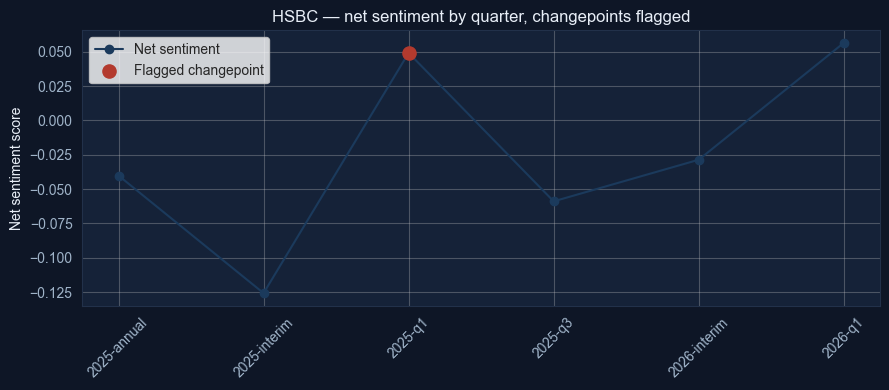

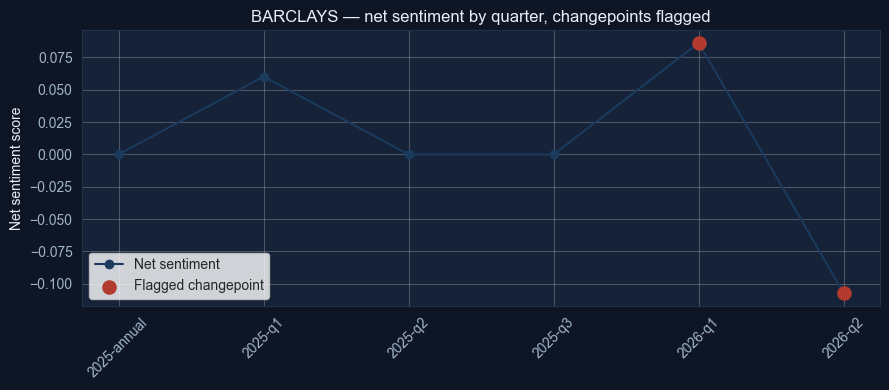

peer_gap matched OK: {'2025-FY': -0.0402, '2025-H1': -0.1258, '2025-H1q1': -0.0111, '2025-Q3': -0.0589, '2026-H1': 0.0785, '2026-H1q1': -0.0298}
  2025-FY: hsbc=-0.0402 barclays=0.0000 gap=-0.0402
  2025-H1: hsbc=-0.1258 barclays=0.0000 gap=-0.1258
  2025-H1q1: hsbc=0.0491 barclays=0.0602 gap=-0.0111
  2025-Q3: hsbc=-0.0589 barclays=0.0000 gap=-0.0589
  2026-H1: hsbc=-0.0287 barclays=-0.1072 gap=0.0785
  2026-H1q1: hsbc=0.0564 barclays=0.0862 gap=-0.0298


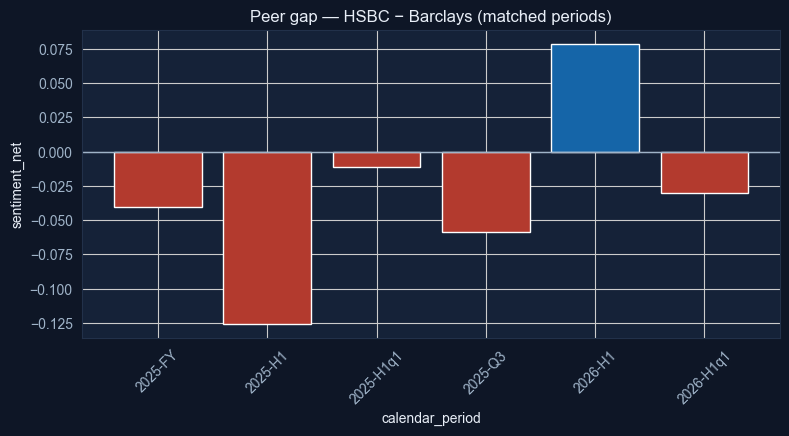

Stage 6.4 matched peer gaps: {'2025-FY': -0.0402, '2025-H1': -0.1258, '2025-H1q1': -0.0111, '2025-Q3': -0.0589, '2026-H1': 0.0785, '2026-H1q1': -0.0298}


In [22]:
corpus_df = _df('corpus_analyst', corpus_df if 'corpus_df' in dir() else None)
## @title 6.4 real temporal + peer
section_header('Stage 6.4 — Real evaluation')

eval_narrative = (
    corpus_df.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'), n_turns=('finbert_net', 'size'))
    if 'finbert_net' in corpus_df.columns
    else _load('narrative_df')
)
eval_narrative = add_calendar_period(eval_narrative)
_save('narrative_df', eval_narrative)

for bank in ['hsbc', 'barclays']:
    series, cps = temporal_comparison(eval_narrative, bank)
    fig, ax = plt.subplots(figsize=(9, 4))
    plot_temporal(series, cps, bank.upper(), ax=ax)
    plt.tight_layout()
    _show_plt(fig, title=f'{bank.upper()} real temporal series')

ax, gap = plot_peer_gap(eval_narrative, use_matched=True)
_show_plt(ax.figure, title='Real peer gap (matched periods)', save_as='peer_gap_matched.png')
print('Stage 6.4 matched peer gaps:', {k: round(float(v), 4) for k, v in gap.items()})
assert '2025-H1' in gap.index, gap.index.tolist()
matched_n = (
    add_calendar_period(eval_narrative)
    .groupby('calendar_period')['bank'].nunique()
    .ge(2).sum()
)
kpi_row([
    ('Matched periods w/ both banks', str(int(matched_n)), 'after interim↔q2 map'),
    ('Raw quarters', str(eval_narrative["quarter"].nunique()), 'pre-match labels'),
])
insight('Temporal + matched peer baselines run on FinBERT scores from the live corpus.', kind='key')


In [23]:
## @title 6.4 real structured-vs-unstructured
section_header('Stage 6.4 — Structured vs unstructured (metric-tagged)')

if 'reported_metrics_df' not in dir() or reported_metrics_df is None or len(reported_metrics_df) == 0:
    reported_metrics_df = _load('reported_metrics')

if 'narrative_df' not in dir() or narrative_df is None or len(narrative_df) == 0:
    narrative_df = _load('narrative_df')

metric_narrative = narrative_df[narrative_df['metric'] != 'overall'].copy()
if metric_narrative.empty:
    metric_narrative = narrative_df.copy()

merged_real = structured_vs_unstructured(
    metric_narrative[['bank', 'quarter', 'metric', 'sentiment_net']],
    reported_metrics_df[['bank', 'quarter', 'metric', 'direction']],
)
if len(merged_real):
    diverging = summarise_divergence(merged_real)
    display_table(merged_real.head(24), title='Structured vs unstructured (metric-tagged narrative)')
    display_table(diverging.head(24), title='Diverging rows')
    _save('structured_vs_unstructured', merged_real)
    kpi_row([
        ('Compared rows', str(len(merged_real)), 'overlaps'),
        ('Divergence', f"{1 - merged_real['agrees'].mean():.0%}", 'tone vs reported'),
    ])
else:
    insight('No overlapping bank/quarter/metric keys — check quarter normalisation.', kind='warn')


Divergence rate: 81% of bank-quarter-metric observations


bank,quarter,metric,sentiment_net,direction,narrative_direction,agrees
barclays,2025-annual,total_income,0.0,up,flat,False
barclays,2025-q1,total_income,0.15317577123641968,up,up,True
barclays,2025-q3,total_income,0.0,up,flat,False
barclays,2026-q1,total_income,0.34464290738105774,up,up,True
barclays,2026-q2,total_income,0.0,up,flat,False
hsbc,2025-q1,total_income,0.08998054265975952,up,flat,False
hsbc,2025-q3,total_income,-0.08103080838918686,up,flat,False
hsbc,2026-q1,total_income,0.0,up,flat,False
barclays,2025-annual,operating_costs,0.0,down,flat,False
barclays,2025-q1,operating_costs,0.0,down,flat,False


bank,quarter,metric,narrative_direction,direction
barclays,2025-annual,total_income,flat,up
barclays,2025-q3,total_income,flat,up
barclays,2026-q2,total_income,flat,up
hsbc,2025-q1,total_income,flat,up
hsbc,2025-q3,total_income,flat,up
hsbc,2026-q1,total_income,flat,up
barclays,2025-annual,operating_costs,flat,down
barclays,2025-q1,operating_costs,flat,down
barclays,2025-q3,operating_costs,flat,down
barclays,2026-q1,operating_costs,flat,down


In [24]:
## @title 6.4 hand validation sample
section_header('Stage 6.4 — Hand validation sample')

def hand_validate_sample(df, n=20, random_state=42):
    """Manual QA — sample n rows for a human to check topic/sentiment labels against the source text."""
    cols = [c for c in ['bank', 'quarter', 'speaker', 'firm', 'topic', 'finbert_sentiment', 'finbert_score', 'ldsa_sentiment', 'text'] if c in df.columns]
    return df[cols].sample(n=min(n, len(df)), random_state=random_state)

validation_sample = hand_validate_sample(corpus_df, n=20)
DOCS_ROOT.mkdir(parents=True, exist_ok=True)
validation_sample.to_csv(HAND_LABELS, index=False)  # INPUT file for human review
display_table(validation_sample.drop(columns=['text'], errors='ignore'), title='Hand-validation sample (text in CSV)')
insight('Wrote hand-label INPUT file — review FinBERT on hedged language.', kind='key')




bank,quarter,speaker,firm,topic,finbert_sentiment,finbert_score,ldsa_sentiment
hsbc,2025-q1,KATHERINE LEI,JP MORGAN,1,neutral,0.8925901651382446,positive
hsbc,2025-interim,KATHERINE LEI,JP MORGAN,1,neutral,0.9281997680664062,negative
barclays,2025-annual,Perlie Mong,Bank of America,0,neutral,0.8209481239318848,neutral
barclays,2026-q2,Edward Firth,KBW,0,neutral,0.8425618410110474,positive
barclays,2025-q3,Chris Cant,Autonomous,-1,neutral,0.8345164060592651,neutral
hsbc,2026-interim,ED FIRTH,KBW,-1,neutral,0.9172082543373108,neutral
hsbc,2025-annual,NICK LORD,MORGAN STANLEY,3,neutral,0.798988938331604,neutral
barclays,2025-q1,Amit Goel,Mediobanca,0,neutral,0.6796335577964783,neutral
hsbc,2026-q1,GUY STEBBINGS,BNP PARIBAS,3,neutral,0.6735067963600159,positive
hsbc,2025-annual,AMAN RAKKAR,BARCLAYS,-1,neutral,0.8768907785415649,positive


In [25]:
## @title 6.4 status
kpi_row([
    ('Temporal', 'live', 'FinBERT by quarter'),
    ('Peer gap', 'live', 'HSBC − Barclays'),
    ('Struct vs unstruct', 'live', 'metric-tagged'),
    ('Hand validation', 'live', 'docs/hand_validation_sample.csv'),
])
insight('All Stage 6 evaluation paths run on the real corpus and Excel packs.', kind='key')


## Stage 7 — Status vs A1 objectives

The deliverable is a **method + evidence**, not a supervisory judgement of HSBC or Barclays. Alert / watch / null (Stages 8–9) packages divergence for a desk; it is not a PRA rating.

**Objectives**

| ID | A1 test | Status in this notebook |
|---|---|---|
| O1 / M1–M2 | Provenance-preserving turns / Q&A pairs by 19 Sep | Stage 1.5 — `corpus_manifest` + 118 `qa_pairs` (date/section/analyst). Bleed-split for Barclays. |
| O2 / M3–M6 | Signals per pair by 30 Sep | Numeric claims + audit sample; Q vs A FinBERT; M6 directness / coverage / substitution on `state_summary` |
| O3 / M7 | Topics mapped to prudential categories, dual-coded by 2 Oct | Stage 3.6 machine dual-code; Aidan human sample still open |
| O4 / M8–M10 | Comparative findings + 1,500-word report + 15-min deck by 12 Oct | Stage 6 views with **n**; report/deck are synthesis (Taz) |

**In the factory**

- [x] Local corpus (M1 fallback: 13 transcripts + 12 packs — logged)
- [x] Parser per bank + Q&A pairing (M2)
- [x] Seeded taxonomy + BERTopic + LDA
- [x] FinBERT on questions **and** answers (Neutral kept)
- [x] Four-metric struct↔Q&A (M3 defined list) + open numeric extract / 50-row audit
- [x] Behavioural signals (M6)
- [x] Eight-category machine map (M7) — human dual-code still Aidan
- [x] Hand sample + label agreement (raise to 60 pairs for M4)
- [x] Episode protocol as **method output** (Stage 8–9)

**Pitch / desk:** [`docs/assignment2/A2_pitch_outline.md`](../docs/assignment2/A2_pitch_outline.md) · Demo `boe-earnings-demo`



In [26]:
## @title 7.0 PRA supervisor readout + re-run cost
section_header('Stage 7.0 — What a PRA supervisor would see')

# Latest available soft signals from live corpus
_corp = corpus_df.copy() if 'finbert_net' in corpus_df.columns else _load('corpus_analyst')
_by_q = (
    _corp.groupby(['bank', 'quarter'], as_index=False)
    .agg(sentiment_net=('finbert_net', 'mean'), n=('text', 'size'))
)
_soft = _by_q.sort_values('sentiment_net').head(4)

_topic1_neg = None
if 'topic' in _corp.columns:
    _t1 = _corp[_corp['topic'] == 1]
    if len(_t1):
        _topic1_neg = (
            _t1.assign(is_neg=_t1['finbert_sentiment'].eq('negative'))
            .groupby('bank')['is_neg'].mean()
        )

# Struct divergence if available
_div = None
if _has('struct_unstruct_agreement'):
    _div = _load('struct_unstruct_agreement')

kpi_row([
    ('Monitor', 'Topic 1', 'costs / forward questions'),
    ('Watch metric', 'credit_impairment', '0% narr↔reported agree (sample)'),
    ('Null case', 'valid', 'no divergence = reportable'),
    ('Re-run cost', '~45–90 min', 'new PDFs + full notebook'),
])

display_table(_soft, title='Softest bank×quarter FinBERT nets (supervisor scan)')
if _topic1_neg is not None:
    display_table(_topic1_neg.rename('topic1_negative_share').reset_index(), title='Topic 1 negative share by bank')

from IPython.display import Markdown
display(Markdown("""
**Positive signal case (act / investigate)**  
- Topic 1 negative share elevated vs prior quarter **and** credit-impairment narrative disagrees with reported ECL direction.  
- Soft FinBERT net on a matched H1/FY window for one bank vs peer.

**Null result case (still reportable)**  
- Topics stable, FinBERT net near flat, structured vs unstructured agree → *no early-warning edge from Q&A this quarter*. That is a valid outcome, not a pipeline failure.

**Cost to re-run next quarter**  
| Step | Effort | Notes |
|---|---|---|
| Drop new IR PDFs + Excel packs | 10–20 min | `data/raw/transcripts/`, `data/structured/` |
| Run notebook Stages 1–7 | 30–60 min CPU | Same `.venv` kernel |
| Optional: re-FT sentiment | +15–30 min | `scripts/finetune_sentiment.py` if labels grow |
| Spot-check hand sample | 15 min | 20–40 turns |
| **Total** | **~45–90 min** | Repeatable pipeline, not a rebuild |
"""))
insight(
    'Supervisor readout: investigate Topic 1 + impairment divergence; treat null (no divergence) as a valid quarterly finding.',
    kind='key',
)


bank,quarter,sentiment_net,n
hsbc,2025-interim,-0.12576009333133698,8
barclays,2026-q2,-0.10720746006284441,7
hsbc,2025-q3,-0.05893149701031772,11
hsbc,2025-annual,-0.040194034576416016,13


bank,topic1_negative_share
barclays,0.0
hsbc,0.125



**Positive signal case (act / investigate)**  
- Topic 1 negative share elevated vs prior quarter **and** credit-impairment narrative disagrees with reported ECL direction.  
- Soft FinBERT net on a matched H1/FY window for one bank vs peer.

**Null result case (still reportable)**  
- Topics stable, FinBERT net near flat, structured vs unstructured agree → *no early-warning edge from Q&A this quarter*. That is a valid outcome, not a pipeline failure.

**Cost to re-run next quarter**  
| Step | Effort | Notes |
|---|---|---|
| Drop new IR PDFs + Excel packs | 10–20 min | `data/raw/transcripts/`, `data/structured/` |
| Run notebook Stages 1–7 | 30–60 min CPU | Same `.venv` kernel |
| Optional: re-FT sentiment | +15–30 min | `scripts/finetune_sentiment.py` if labels grow |
| Spot-check hand sample | 15 min | 20–40 turns |
| **Total** | **~45–90 min** | Repeatable pipeline, not a rebuild |


In [27]:
## @title 7.1 Closing KPI strip
section_header('Stage 7 — Pipeline complete')
n_pdfs = len(list(RAW_ROOT.rglob('*.pdf'))) if RAW_ROOT.exists() else 0
n_xlsx = len(list(STRUCTURED_ROOT.rglob('*.xlsx'))) if STRUCTURED_ROOT.exists() else 0
n_analyst = len(_load('corpus_analyst')) if _has('corpus_analyst') else 0
n_metrics = len(_load('reported_metrics')) if _has('reported_metrics') else 0
n_narr = len(_load('narrative_df')) if _has('narrative_df') else 0
n_coh = _has('topic_coherence')
n_match = _has('peer_matched_quarters')
kpi_row([
    ('Transcript PDFs', str(n_pdfs), 'HSBC + Barclays'),
    ('Analyst turns', str(n_analyst), 'cleaned corpus'),
    ('Coherence / matched peer', f"{'yes' if n_coh else 'no'} / {'yes' if n_match else 'no'}", 'A2 extras'),
    ('Narrative rows', str(n_narr), 'metric-tagged'),
])
insight('A2 notebook gaps filled — re-run all cells once to refresh displays and write new CSVs.', kind='key')


## Stage 8 — Episode protocol (method output, not a firm rating)

**A1 exclusion:** we do not conclude either firm's actual prudential condition. This stage records **one worked example** of the method: HSBC 2025-interim, with evidence IDs, so Taz can trace findings (M9).

Alert / watch / null is a **rule on tone vs packs vs peer**, for a re-runnable pack — not a PRA judgement.

Artifacts: `scripts/build_supervisory_episode.py` → `data/boe.sqlite`.

A2: [`../docs/assignment2/README.md`](../docs/assignment2/README.md)


In [28]:
## @title 8.1 Build / load supervisory episode
section_header('Stage 8.1 — HSBC H1 2025 supervisory episode', 'Softest print + matched peer + struct pack')

import json, subprocess, sys
if not _has_json('supervisory_episode'):
    subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'build_supervisory_episode.py')])
else:
    # refresh so briefs stay in sync with corpus
    subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'build_supervisory_episode.py')])

_hydrate()  # refresh after product scripts
episode = _load_json('supervisory_episode')
briefs = _load('episode_metric_briefs')
quotes = _load('episode_quotes')
timeline = _load('event_timeline')
protocol = _load('alert_null_protocol')
topic_share = _load('episode_topic_share')

kpi_row([
    ('Episode', f"{episode['bank'].upper()} {episode['quarter']}", episode['calendar_period']),
    ('FinBERT net', f"{episode['finbert_net']:.3f}", f"{episode['n_turns']} turns"),
    ('Topic 1 neg', f"{episode['topic1_neg_share']:.0%}", f"{episode['topic1_turns']} turns"),
    ('Peer gap', f"{episode['peer_gap_hsbc_minus_barclays']:.3f}" if episode['peer_gap_hsbc_minus_barclays'] is not None else 'n/a', 'HSBC−Barclays H1'),
])
insight(episode['headline'], kind='key')
insight(f"Protocol verdict: **{episode['verdict']}** (rules fired: {', '.join(episode['rules_fired'])})", kind='key')
display_table(topic_share, title='Episode topic mix')
display_table(timeline, title='Event timeline (episode-centred)')


[
  {
    "id": "hsbc_2025_h1",
    "label": "HSBC 2025-interim (H1)",
    "bank": "hsbc",
    "quarter": "2025-interim",
    "calendar_period": "2025-H1",
    "struct_quarter": "2025-q2",
    "n_turns": 8,
    "finbert_net": -0.12576009333133698,
    "topic1_turns": 2,
    "topic1_neg_share": 0.5,
    "peer_gap_hsbc_minus_barclays": -0.12576009333133698,
    "peer_hsbc_net": -0.12576009333133698,
    "peer_barclays_net": 0.0,
    "peer_hsbc_n": 8,
    "peer_barclays_n": 6,
    "peer_hsbc_non_neutral_share": 0.25,
    "peer_barclays_non_neutral_share": 0.0,
    "peer_usable_for_a2": false,
    "peer_caveat": "Matched 2025-H1 has both banks, but one side is 100% FinBERT-neutral (HSBC net=-0.126, n=8, non-neut=25%; Barclays net=0.000, n=6, non-neut=0%). Gap -0.126 is not treated as an A2 alert.",
    "rules_fired": [
      "A3"
    ],
    "verdict": "WATCH \u2014 soft Q&A tone but narrative broadly agrees with pack directions",
    "headline": "HSBC 2025-interim (H1): FinBERT net -0.13; 

topic,n,finbert_net,neg_share,episode_id,bank,quarter
-1,3,-0.15321379899978638,0.3333333333333333,hsbc_2025_h1,hsbc,2025-interim
0,1,0.0,0.0,hsbc_2025_h1,hsbc,2025-interim
1,2,-0.27321967482566833,0.5,hsbc_2025_h1,hsbc,2025-interim
2,1,0.0,0.0,hsbc_2025_h1,hsbc,2025-interim
4,1,0.0,0.0,hsbc_2025_h1,hsbc,2025-interim
-1,3,0.0,0.0,barclays_2026_h1,barclays,2026-q2
0,3,0.0,0.0,barclays_2026_h1,barclays,2026-q2
3,1,-0.7504522204399109,1.0,barclays_2026_h1,barclays,2026-q2


episode_id,date_anchor,bank,event,signal
hsbc_2025_h1,2025-H1,hsbc,HSBC 2025-interim (H1) — supervisory episode window,finbert_net=-0.126; Topic 1 dominates (2 turns)
hsbc_2025_h1,2025-q2,hsbc,Structured data pack directions,total_income=down; credit_impairment=down; operating_costs=down; cet1_ratio=flat
hsbc_2025_h1,2025-H1 peer,both,Matched peer window,HSBC−Barclays gap=-0.126
barclays_2026_h1,2026-H1,barclays,Barclays 2026-q2 (H1) — supervisory episode window,finbert_net=-0.107; Topic 1 dominates (0 turns)
barclays_2026_h1,2026-q2,barclays,Structured data pack directions,total_income=up; operating_costs=down; credit_impairment=down; cet1_ratio=flat
barclays_2026_h1,2026-H1 peer,both,Matched peer window,HSBC−Barclays gap=0.079


In [29]:
## @title 8.2 Claim-vs-source metric briefs + quotes
section_header('Stage 8.2 — Claim vs source (faithfulness)')

display_table(
    briefs[[c for c in ['metric', 'reported_direction', 'narrative_direction', 'qa_finbert_net', 'n_qa_hits', 'faithful', 'claim'] if c in briefs.columns]],
    title='Metric briefs — reported pack vs Q&A tone',
)
display_table(quotes, title='Representative analyst quotes (clipped)')

disagree = briefs[briefs['faithful'] == False] if 'faithful' in briefs.columns else briefs.iloc[0:0]
kpi_row([
    ('Metrics checked', str(len(briefs)), 'income · costs · impairment · CET1'),
    ('Disagree / watch', str(len(disagree)), 'claim vs reported direction'),
    ('Struct quarter', episode['struct_quarter'], 'pack matched to interim'),
])
insight(
    'Faithfulness here = does Q&A tone direction match the Excel pack direction? Disagreement is the BoE research signal — not a model accuracy score.',
    kind='info',
)


metric,reported_direction,narrative_direction,qa_finbert_net,n_qa_hits,faithful,claim
credit_impairment,down,down,-0.20121614933013915,5,1.0,Reported credit_impairment moved down (-876.0→-1065.0); Q&A tone on related turns is down (net=-0.20).
operating_costs,down,down,-0.11491034924983978,4,1.0,Reported operating_costs moved down (-8102.0→-8920.0); Q&A tone on related turns is down (net=-0.11).
cet1_ratio,flat,flat,0.0,3,1.0,Reported cet1_ratio moved flat (0.147→0.146); Q&A tone on related turns is flat (net=0.00).
total_income,down,down,-0.10928786993026733,5,1.0,Reported total_income moved down (17649.0→16473.0); Q&A tone on related turns is down (net=-0.11).
credit_impairment,down,None,nan,0,nan,Reported credit_impairment direction=down on 2026-q2; no clear Q&A hit.
operating_costs,down,flat,0.0,2,0.0,Reported operating_costs moved down (-8407.0→-8873.0); Q&A tone on related turns is flat (net=0.00).
cet1_ratio,flat,None,nan,0,nan,Reported cet1_ratio direction=flat on 2026-q2; no clear Q&A hit.
total_income,up,down,-0.18761305510997772,4,0.0,Reported total_income moved up (14896.0→16501.0); Q&A tone on related turns is down (net=-0.19).


speaker,firm,topic,finbert_sentiment,finbert_score,text,episode_id,bank,quarter
KIAN ABOUHOSSEIN,JP MORGAN,1,negative,0.5464393496513367,"Two questions: the first one is related to tariffs. You gave guidance of 5% impact on revenues and I just wanted to see how we should think about that going forward, as you don’t see anything in the numbers today. And the second question is related to stage 1 and stage 2 movements. Clearly, your stage 2 has deteriorated. You discuss PDs, which have been adjusted, and I’m trying to understand a li…",hsbc_2025_h1,hsbc,2025-interim
KUNPENG MA,CHINA SECURITIES,-1,negative,0.45964139699935913,"I have two questions on impairments. The first one is related to the BoCom impairment, especially that one with the VIU test. It seems that you conduct a VIU test every quarter, but you don’t charge impairments every quarter. It seems that the impairment charges always come together with other bad news. When you first charge the VIU impairment in the fourth quarter of 2023, you got French disposa…",hsbc_2025_h1,hsbc,2025-interim
KATHERINE LEI,JP MORGAN,1,neutral,0.9281997680664062,"I have three questions. The first is that I would want to ask about what are the outstanding parts of the threshold deduction related to the BoCom, if there is further impairment on BoCom? If there’s further impairment on BoCom, what would the amount be in order for that future impairment to have an impact on your CET1 ratios and share buyback and EPS, and so forth? Number two is related to the $…",hsbc_2025_h1,hsbc,2025-interim
KENDRA YAN,CICC,2,neutral,0.8659449815750122,"I have two questions. The first is about the non-interest income. I’ve seen that HSBC delivered quite strong non-interest income in both quarter one and quarter two, primarily driven by the wealth management FX and the capital markets-related business. I wonder how you see the sustainability of this momentum going forward. The second question is about the stablecoin, because there are several cou…",hsbc_2025_h1,hsbc,2025-interim
JOSEPH DICKERSON,JEFFERIES,-1,neutral,0.835599958896637,"Just a simple follow-up on the Hong Kong CRE, which I think you’ve done a pretty good job of addressing. I guess what drove the timing of this charge, because some of the dynamics that you point out in the interim report you could have easily argued were there in Q4, so I guess what drove the timing of today versus Q4? And then, is there any way to gauge what you think the appropriate coverage le…",hsbc_2025_h1,hsbc,2025-interim
Benjamin Toms,RBC,3,negative,0.7504522204399109,"Good morning both. Thank you for taking my question. The �rst one's on PBWM. Net New AUM in PBWM in Q2 was relatively weak. What's impacting performance here? I think I was a little surprised, my feeling was you've been quite active in trying to make your proposition more attractive in this space.",barclays_2026_h1,barclays,2026-q2
Benjamin Toms,RBC,-1,neutral,0.9108616709709167,"Thank you. Anna Cross Okay, thank you, Ben. Perhaps we could go to the next question, please.",barclays_2026_h1,barclays,2026-q2
Jonathan Pierce,Jeferies,-1,neutral,0.8746339678764343,Okay thanks very much. Anna Cross,barclays_2026_h1,barclays,2026-q2
Amit Goel,Mediobanca,0,neutral,0.8450940251350403,"Hi, thank you. I've got two questions. So one, just coming back on the additional SCAs, I was actually a bit surprised by the 100% return on investment. So, I just really wanted to understand a bit better, like if the returns on that type of investment are so high, wouldn't the Group be doing that kind of investment in any case? And, why limit it at the amounts being done? Why not more? And then …",barclays_2026_h1,barclays,2026-q2
Edward Firth,KBW,0,neutral,0.8425618410110474,"The only thing I would add is that, on your Slide 10, you show £1.2 billion of additional revenue from the hedge and yet if I'm looking at your guidance, banking NII is not going to grow by £1.2 billion, it's going to be somewhat less than that. So that would s

In [30]:
## @title 8.3 Alert / watch / null protocol
section_header('Stage 8.3 — Alert vs null protocol')

display_table(protocol, title='Decision rules (product layer)')

fired = set(episode['rules_fired'])
protocol_view = protocol.copy()
protocol_view['fired'] = protocol_view['rule_id'].isin(fired)
display_table(protocol_view, title='Rules fired on this episode')

from IPython.display import Markdown
display(Markdown(f"""
### Supervisor readout — {episode['bank'].upper()} {episode['calendar_period']}

**Verdict:** {episode['verdict']}

**Positive / act case:** Topic 1 negatives + impairment narrative disagreeing with the pack, and/or a large matched peer gap → desk pulls quotes and ECL tables.

**Null case:** If themes and metrics agree and tone is flat → write *“no early-warning edge from Q&A this quarter.”* That is a success for the protocol, not a failed model.

**Pipelines behind this:** ingest → topics → sentiment → baselines → **decision rules** (see `docs/assignment2/README.md`).
"""))
insight('Stage 8 turns the NLP stack into a supervisory product: episode + rules + re-run ops.', kind='key')


rule_id,severity,condition,action
A1,alert,Topic 1 negative share rises vs prior print AND credit_impairment narrative disagrees with reported direction,Desk review: pull Q&A quotes + ECL pack; escalate if both persist next quarter
A2,alert,"Matched peer gap (HSBC−Barclays) < −0.10 on H1/FY, both banks n≥3, and peer side not 100% FinBERT-neutral",Compare cost/impairment themes across banks; check if idiosyncratic or sector
A3,watch,FinBERT net soft (< −0.08) but structured metrics agree with narrative,Log only — tone soft without metric contradiction
N1,null,"Topics stable, FinBERT net ≈ flat, structured↔unstructured agree",Report ‘no early-warning edge from Q&A this quarter’ — valid outcome


rule_id,severity,condition,action,fired
A1,alert,Topic 1 negative share rises vs prior print AND credit_impairment narrative disagrees with reported direction,Desk review: pull Q&A quotes + ECL pack; escalate if both persist next quarter,False
A2,alert,"Matched peer gap (HSBC−Barclays) < −0.10 on H1/FY, both banks n≥3, and peer side not 100% FinBERT-neutral",Compare cost/impairment themes across banks; check if idiosyncratic or sector,False
A3,watch,FinBERT net soft (< −0.08) but structured metrics agree with narrative,Log only — tone soft without metric contradiction,True
N1,null,"Topics stable, FinBERT net ≈ flat, structured↔unstructured agree",Report ‘no early-warning edge from Q&A this quarter’ — valid outcome,False



### Supervisor readout — HSBC 2025-H1

**Verdict:** WATCH — soft Q&A tone but narrative broadly agrees with pack directions

**Positive / act case:** Topic 1 negatives + impairment narrative disagreeing with the pack, and/or a large matched peer gap → desk pulls quotes and ECL tables.

**Null case:** If themes and metrics agree and tone is flat → write *“no early-warning edge from Q&A this quarter.”* That is a success for the protocol, not a failed model.

**Pipelines behind this:** ingest → topics → sentiment → baselines → **decision rules** (see `docs/assignment2/README.md`).


## Stage 9 — Publish artefacts for A2 / A3

Last mile: versioned files the next stage consumes (A1: artefacts passed between stages).

1. Two episode windows (HSBC H1 2025 + Barclays H1 2026) as **examples of the method**
2. One-page notes (evidence, not a rating)
3. Extractive metric briefs on the four scoped lines
4. Label-agreement numbers (honest M4 sample size)
5. Sync → Demo `desk.sqlite`

Re-run: [`docs/assignment2/README.md`](../docs/assignment2/README.md). Scripts: `build_supervisory_episode.py` · `generate_pra_note.py` · `build_metric_briefs.py` · `label_agreement.py`.


In [31]:
## @title 9.1 Dual episodes + PRA notes
section_header('Stage 9.1 — Dual episodes & PRA one-pagers')

import json, subprocess, sys
from IPython.display import Markdown

subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'build_supervisory_episode.py')])
subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'generate_pra_note.py')])
subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'build_metric_briefs.py')])
subprocess.check_call([sys.executable, str(ROOT / 'scripts' / 'label_agreement.py')])
_hydrate()  # refresh after product scripts

episodes = _load_json('supervisory_episodes')
briefs = _load('episode_metric_briefs')
faith = _load('metric_briefs_faithful')

display_table(pd.DataFrame(episodes)[[
    'label', 'n_turns', 'finbert_net', 'topic1_neg_share',
    'peer_gap_hsbc_minus_barclays', 'verdict'
]], title='Supervisory episodes (HSBC + Barclays)')

kpi_row([
    ('Episodes', str(len(episodes)), 'HSBC H1 + Barclays H1'),
    ('PRA notes', '2', 'docs/assignment2/pra_notes/'),
    ('Faithful briefs', str(len(faith)), f"mean overlap {faith['faithfulness_overlap'].mean():.2f}"),
    ('Re-run cost', '45–90 min', 'checklist in assignment2/'),
])

for ep in episodes:
    tone = 'key' if 'ALERT' in ep['verdict'] else 'info'
    insight(f"{ep['label']}: {ep['verdict']}", kind=tone)

try:
    _pra = _load_text('pra_notes.md')
    display(Markdown('### PRA notes pack (preview)\n\n' + _pra[:1800] + '\n\n…'))
except FileNotFoundError:
    pass

display_table(
    faith.head(12)[['bank', 'quarter', 'metric', 'method', 'faithfulness_overlap', 'summary']],
    title='Extractive metric briefs (faithfulness = token overlap with source)',
)
insight(
    'Automation pipeline publish: IR → episodes → PRA → desk. '
    'Open sibling Demo (boe-earnings-demo) or see docs/assignment2/A2_pitch_outline.md.',
    kind='key',
)


[
  {
    "id": "hsbc_2025_h1",
    "label": "HSBC 2025-interim (H1)",
    "bank": "hsbc",
    "quarter": "2025-interim",
    "calendar_period": "2025-H1",
    "struct_quarter": "2025-q2",
    "n_turns": 8,
    "finbert_net": -0.12576009333133698,
    "topic1_turns": 2,
    "topic1_neg_share": 0.5,
    "peer_gap_hsbc_minus_barclays": -0.12576009333133698,
    "peer_hsbc_net": -0.12576009333133698,
    "peer_barclays_net": 0.0,
    "peer_hsbc_n": 8,
    "peer_barclays_n": 6,
    "peer_hsbc_non_neutral_share": 0.25,
    "peer_barclays_non_neutral_share": 0.0,
    "peer_usable_for_a2": false,
    "peer_caveat": "Matched 2025-H1 has both banks, but one side is 100% FinBERT-neutral (HSBC net=-0.126, n=8, non-neut=25%; Barclays net=0.000, n=6, non-neut=0%). Gap -0.126 is not treated as an A2 alert.",
    "rules_fired": [
      "A3"
    ],
    "verdict": "WATCH \u2014 soft Q&A tone but narrative broadly agrees with pack directions",
    "headline": "HSBC 2025-interim (H1): FinBERT net -0.13; 

label,n_turns,finbert_net,topic1_neg_share,peer_gap_hsbc_minus_barclays,verdict
HSBC 2025-interim (H1),8,-0.12576009333133698,0.5,-0.12576009333133698,WATCH — soft Q&A tone but narrative broadly agrees with pack directions
Barclays 2026-q2 (H1),7,-0.10720746006284441,0.0,0.078533324980198,WATCH — soft Q&A tone but narrative broadly agrees with pack directions


### PRA notes pack (preview)

# PRA supervisory note — HSBC 2025-interim (H1)

**Date:** 2026-09-13 · **Group 9** · Bank of England employer project  
**Window:** 2025-H1 (narrative `2025-interim` · pack `2025-q2`)

---

## Verdict

**WATCH — soft Q&A tone but narrative broadly agrees with pack directions**

HSBC 2025-interim (H1): FinBERT net -0.13; Topic 1=2 turns; peer on 2025-H1: HSBC=-0.126 (n=8) vs Barclays=0.000 (n=6); gap=-0.126 — Matched 2025-H1 has both banks, but one side is 100% FinBERT-neutral (HSBC net=-0.126, n=8, non-neut=25%; Barclays net=0.000, n=6, non-neut=0%). Gap -0.126 is not treated as an A2 alert.

| KPI | Value |
|---|---|
| Analyst turns | 8 |
| FinBERT net | -0.126 |
| Topic 1 turns / neg share | 2 / 50% |
| Peer sides (matched) | HSBC -0.126 (n=8, non-neut 25%) · Barclays 0.000 (n=6, non-neut 0%) |
| Peer gap (HSBC − Barclays) | -0.126 · **not used for A2** |
| Rules fired | A3 |

**Peer caveat:** Matched 2025-H1 has both banks, but one side is 100% FinBERT-neutral (HSBC net=-0.126, n=8, non-neut=25%; Barclays net=0.000, n=6, non-neut=0%). Gap -0.126 is not treated as an A2 alert.

---

## Struct vs Q&A (claim check)

| Metric | Reported | Q&A tone | Agree? |
|---|---|---|---|
| credit_impairment | down | down | n/a |
| operating_costs | down | down | n/a |
| cet1_ratio | flat | flat | n/a |
| total_income | down | down | n/a |

*Agree? = yes/no only when Q&A tone exists; **n/a** if no metric hits in the episode (absence ≠ agreement).*

---

## Protocol

| Rule | Severity | This note | Condition |
|---|---|---|---|
| A1 | alert | — | Topic 1 negative share rises vs prior print AND credit_impairment narrative disagrees with reported direction |
| A2 | alert | — | Matched peer gap (HSBC−Barclays) < −0.10 on H1/FY, both banks n≥3, and peer side not 100% FinBERT-neutral |
| 

…

bank,quarter,metric,method,faithfulness_overlap,summary
hsbc,2025-interim,total_income,extractive,1.0,"You gave guidance of 5% impact on revenues and I just wanted to see how we should think about that going forward, as you don’t see anything in the numbers today."
hsbc,2025-interim,operating_costs,extractive,1.0,Metric (operating costs / efficiency) not clearly discussed in this turn.
hsbc,2025-interim,credit_impairment,extractive,1.0,And the second question is related to stage 1 and stage 2 movements.
hsbc,2025-interim,cet1_ratio,extractive,1.0,Metric (CET1 / capital ratio) not clearly discussed in this turn.
hsbc,2025-interim,total_income,extractive,1.0,Metric (total income / NII / revenue) not clearly discussed in this turn.
hsbc,2025-interim,operating_costs,extractive,1.0,"You increased the credit cost assumption going forward due to the Hong Kong CRE pressure. When you first charge the VIU impairment in the fourth quarter of 2023, you got French disposal loss, you got a slight miss on the cost control, so you charged the first time and, in this quarter, you got the BoCom dilution impairment."
hsbc,2025-interim,credit_impairment,extractive,1.0,"It seems that VIU impairment charges always come together with other bad news. The first one is related to the BoCom impairment, especially that one with the VIU test."
hsbc,2025-interim,cet1_ratio,extractive,1.0,Metric (CET1 / capital ratio) not clearly discussed in this turn.
hsbc,2025-interim,total_income,extractive,1.0,Metric (total income / NII / revenue) not clearly discussed in this turn.
hsbc,2025-interim,operating_costs,extractive,1.0,Number two is related to the $0.6 billion of restructuring-related costs.
